# this notebook generates the plots comparing the tcrbridge scores of the TCR-pMHC scores of cognate epitope versus all other (swapped) epitopes 
figures 5, S5 AUC and score plots


### imports

In [ ]:
import json
import pandas as pd 
import os
import numpy as np
import random
from pathlib import Path
import sys
# from Bio.Data import IUPACData
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay, confusion_matrix
import seaborn as sns

### set parameters

In [ ]:
from matplotlib import rcParams
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.font_manager as fm 

def set_mpl_params(mpl):
    mylines = 0.75 # pt updated
    mpl.rcParams['axes.linewidth'] = mylines # default 1
    mpl.rcParams['ytick.direction'] = 'out' # default 'in'
    mpl.rcParams['xtick.direction'] = 'out' # default 'in'
    mpl.rcParams['xtick.major.size'] = 3.5 # default 4
    mpl.rcParams['ytick.major.size'] = 3.5 # default 4
    mpl.rcParams['xtick.major.width'] = mylines # default 0.5
    mpl.rcParams['ytick.major.width'] = mylines # default 0.5
    mpl.rcParams['grid.linewidth'] = mylines/1.5# default 0.5
    mpl.rcParams['grid.color'] = '0.8' # default 'k'
    mpl.rcParams['grid.linestyle'] = 'solid'# default ':'
    mpl.rcParams['legend.frameon'] = False # default True
    mpl.rcParams['font.family'] = 'Arial' # added
    mpl.rcParams['figure.dpi']= 300
    mpl.rc("savefig", dpi=300)
    mpl.rcParams['pdf.fonttype'] = 42 # embed fonts as editable text in illustrator
    mpl.rcParams['ps.fonttype'] = 42 # embed fonts as editable text in illustrator
    mpl.rcParams['figure.autolayout'] = True  # set tight layout to always true

    mpl.rcParams['xtick.labelsize'] = 7  # X-axis tick labels
    mpl.rcParams['ytick.labelsize'] = 7  # Y-axis tick labels

    return mpl, mylines

data_path_swap = ''
out_path_dropbox = ''

SAVE_DROPBOX = False
SAVE_FIGS = False
# fm.fontManager.addfont("/home/b.kwee/.fonts/ARIAL.TTF") # on cluster
fm.fontManager.addfont("/Library/Fonts/Arial Unicode.ttf") # local
mpl, mylines = set_mpl_params(mpl)
linewidth = mylines
figsize_prc_auc = (5/2.54, 4/2.54)
dotsize = 12
fontsize_axes = 7
background_alpha = 0.45
color_alpha = 0.6

import sys
sys.path.append('../')

from parse_output import *
subset_pos_only = False

with open('name_color_dict_rebuttal.json', 'r') as f:
    name_color_dict = json.load(f)

### load data

In [ ]:
import pandas as pd
labels_df = pd.read_json(data_path_swap + 'experiment_set_stats_all-v-1.json')
dataset_swap_part1 = pd.read_csv(data_path_swap + "swap_after_ray/tcr_production_swap_dataframe/part1/df_alphabridge_rmsf_pre_msa_tcr_production_swap_v4.csv")
dataset_swap_part2 = pd.read_csv(data_path_swap + "swap_after_ray/tcr_production_swap_dataframe/part2/df_alphabridge_rmsf_pre_msa_tcr_production_swap_part2.csv")
dataset_swap = pd.concat([dataset_swap_part1,dataset_swap_part2]).reset_index(drop=True)

dataset_cognate = pd.read_csv(data_path_swap + 'tcr_production_val_nonval_v4/df_alphabridge_rmsf_pre_msa_tcr_production_val_nonval_v4.csv')
dataset_cognate['epitope_cognate']  = dataset_cognate['TCR_name'].str.split('_').str[-1].str.upper()
dataset_cognate['epitope_swap']  = dataset_cognate['TCR_name'].str.split('_').str[-1].str.upper()
dataset_cognate['tcr_id'] = dataset_cognate['TCR_name'].str.upper()

dataset_swap['epitope_swap'] = dataset_swap['TCR_name'].str.split('_').str[-1].str.upper().str.split("-").str[0]
dataset_swap['epitope_cognate'] = dataset_swap['TCR_name'].str.split('_').str[-2].str.upper()
dataset_swap['tcr_id'] = dataset_swap['TCR_name'].str.upper().str.split('_').str[0:-1].str.join(sep="_")
print(len(dataset_swap))

# load tcrvdb labels
labels_all_epitopes = pd.read_json(data_path_swap + 'experiment_set_stats_all-v-1.json')

all_epitopes_for_swap = list(dataset_cognate['TCR_name'].str.split('_').str[-1].str.upper().unique())

9247


### check numbers

In [19]:
all_epitope_preds = {}
for epitope in all_epitopes_for_swap:
    print()
    print(epitope)
    cognate_preds = dataset_cognate[dataset_cognate['epitope_cognate'] == epitope].copy().reset_index(drop=True)
    print(len(cognate_preds),'all')
    
    epi_labels_subset = labels_all_epitopes[epitope].T
    pos_ids = epi_labels_subset['pos_ids']
    cognate_preds_pos = cognate_preds[cognate_preds['TCR_name'].str.upper().isin(pos_ids)].copy().reset_index(drop=True)
    print(len(cognate_preds_pos), 'pos')

    swap_preds_subset = dataset_swap[dataset_swap['epitope_cognate'] == epitope].copy().reset_index(drop=True)
    print(len(swap_preds_subset), 'swap preds')
    print(len(swap_preds_subset)/len(cognate_preds_pos), 'ratio swap : pos')

    cognate_preds_pos['ABi_score_A_C'] = cognate_preds_pos['ABi_score_A_C'].fillna(value=0)
    cognate_preds_pos['ABi_score_B_C'] = cognate_preds_pos['ABi_score_B_C'].fillna(value=0)
    swap_preds_subset['ABi_score_A_C'] = swap_preds_subset['ABi_score_A_C'].fillna(value=0)
    swap_preds_subset['ABi_score_B_C'] = swap_preds_subset['ABi_score_B_C'].fillna(value=0)

    cognate_preds_pos['tcrbridge'] = (cognate_preds_pos['ABi_score_A_C'] + cognate_preds_pos['ABi_score_B_C'])/2
    swap_preds_subset['tcrbridge'] = (swap_preds_subset['ABi_score_A_C'] + swap_preds_subset['ABi_score_B_C'])/2

    subset_columns = ['tcr_id', 'epitope_cognate','epitope_swap','tcrbridge']
    cognate_preds_pos = cognate_preds_pos[subset_columns]
    swap_preds_subset = swap_preds_subset[subset_columns]

    epitope_all_preds = pd.concat([cognate_preds_pos,swap_preds_subset]).reset_index(drop=True)
    
    epitope_all_preds['is_cognate'] = epitope_all_preds['epitope_cognate'] == epitope_all_preds['epitope_swap']
    df_wide = epitope_all_preds.pivot_table(
        index=['tcr_id', 'epitope_cognate'],
        columns='epitope_swap',
        values='tcrbridge'
    ).reset_index()

#     # Optional: rename columns
    df_wide.columns.name = None
    df_wide = df_wide.rename(columns=lambda x: f"score_{x}" if x not in ['tcr_id', 'epitope_cognate'] else x)
    all_epitope_preds[epitope] = df_wide


LLWNGPMAV
232 all
162 pos
1134 swap preds
7.0 ratio swap : pos

GLCTLVAML
195 all
110 pos
770 swap preds
7.0 ratio swap : pos

NLVPMVATV
371 all
91 pos
637 swap preds
7.0 ratio swap : pos

GILGFVFTL
675 all
381 pos
2667 swap preds
7.0 ratio swap : pos

TTDPSFLGRY
389 all
170 pos
1190 swap preds
7.0 ratio swap : pos

YLQPRTFLL
430 all
158 pos
1106 swap preds
7.0 ratio swap : pos

LTDEMIAQY
132 all
75 pos
525 swap preds
7.0 ratio swap : pos

CINGVCWTV
243 all
174 pos
1218 swap preds
7.0 ratio swap : pos


### manual inspection of prediction scores

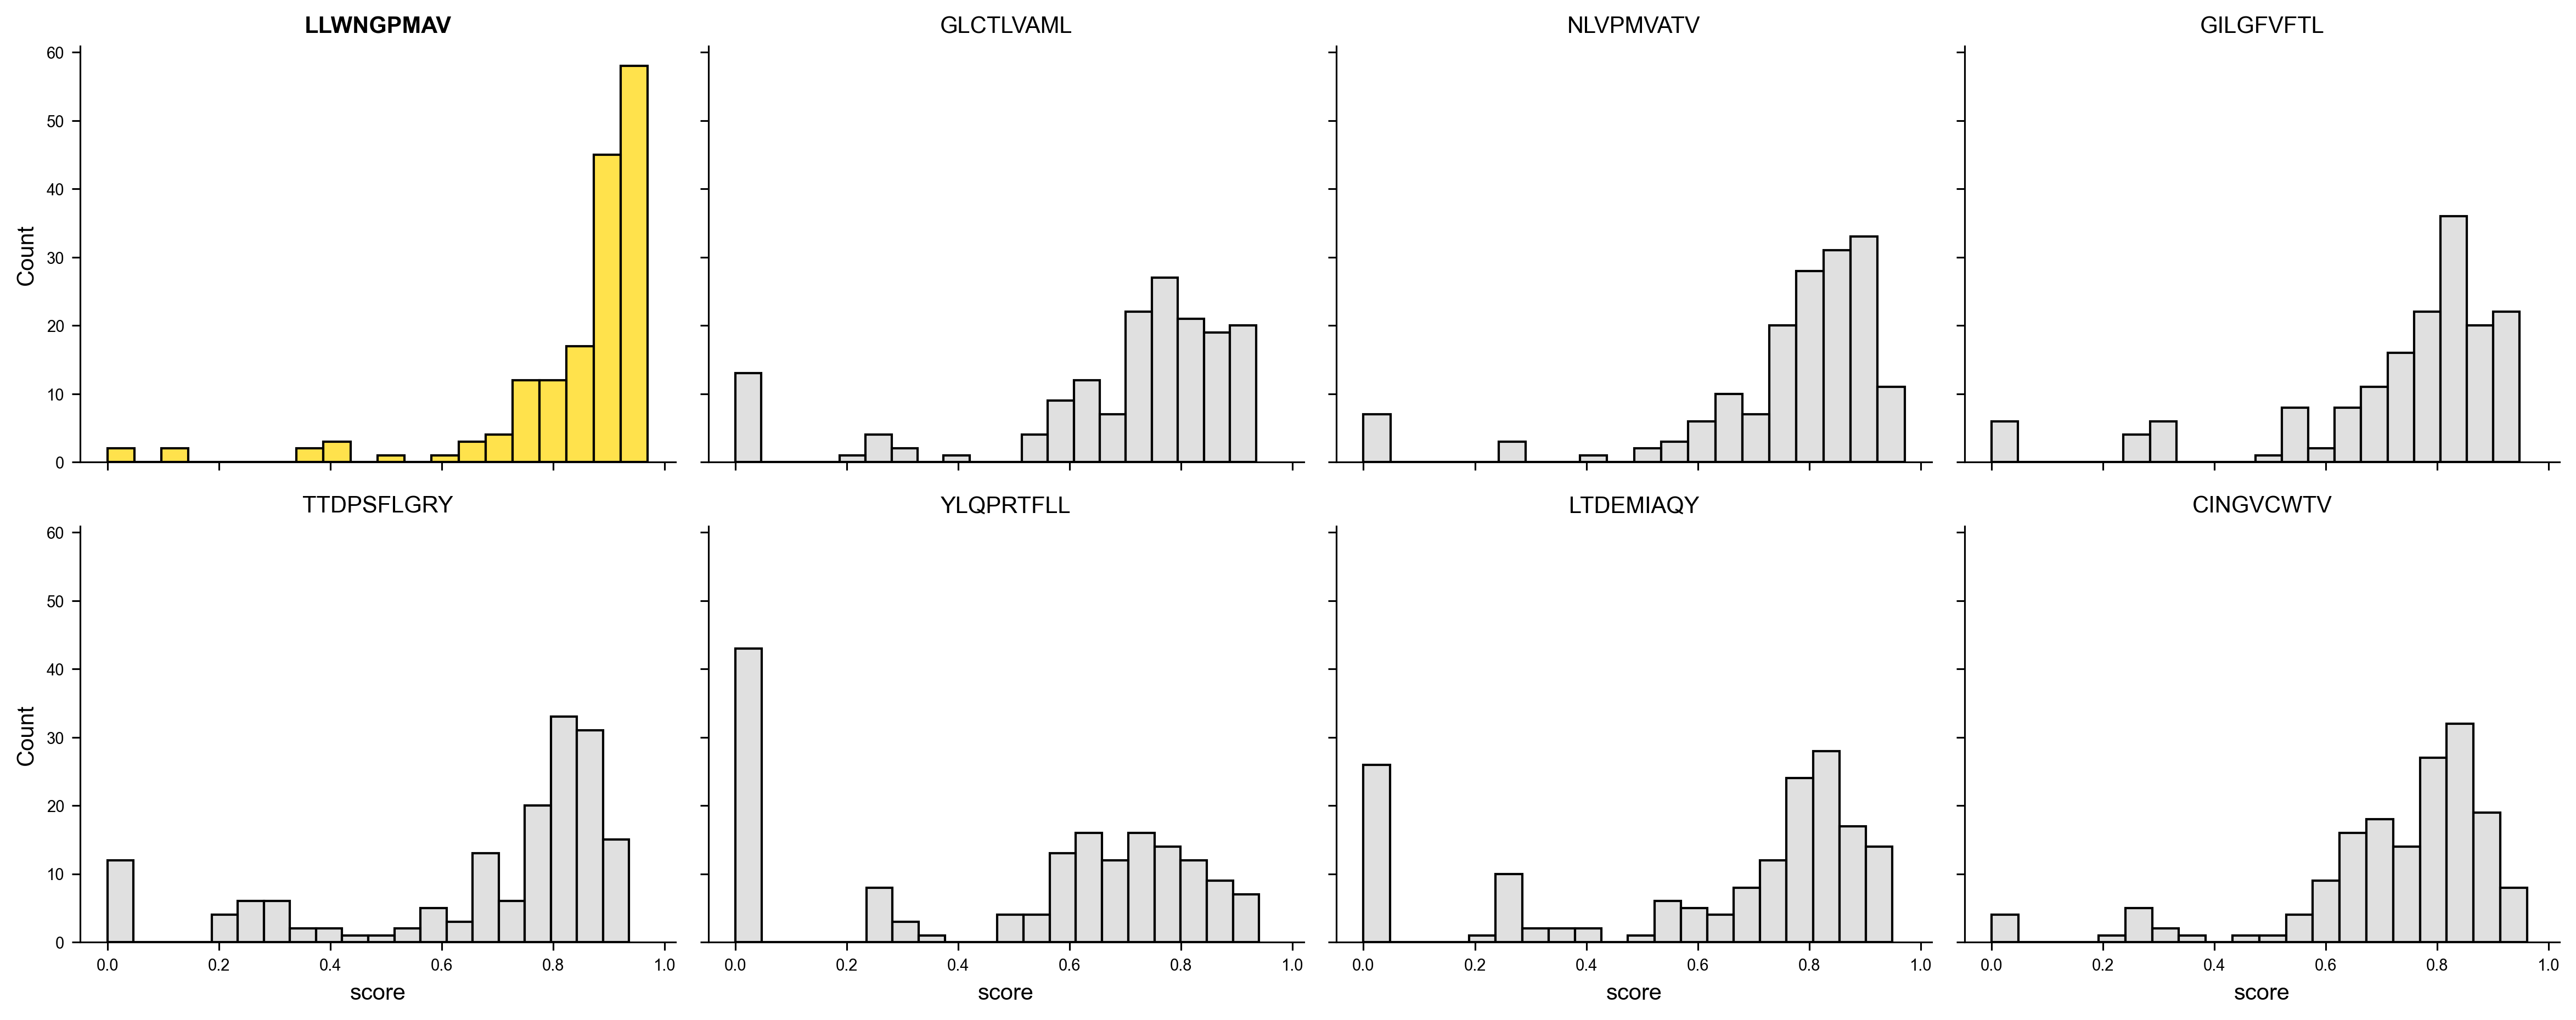

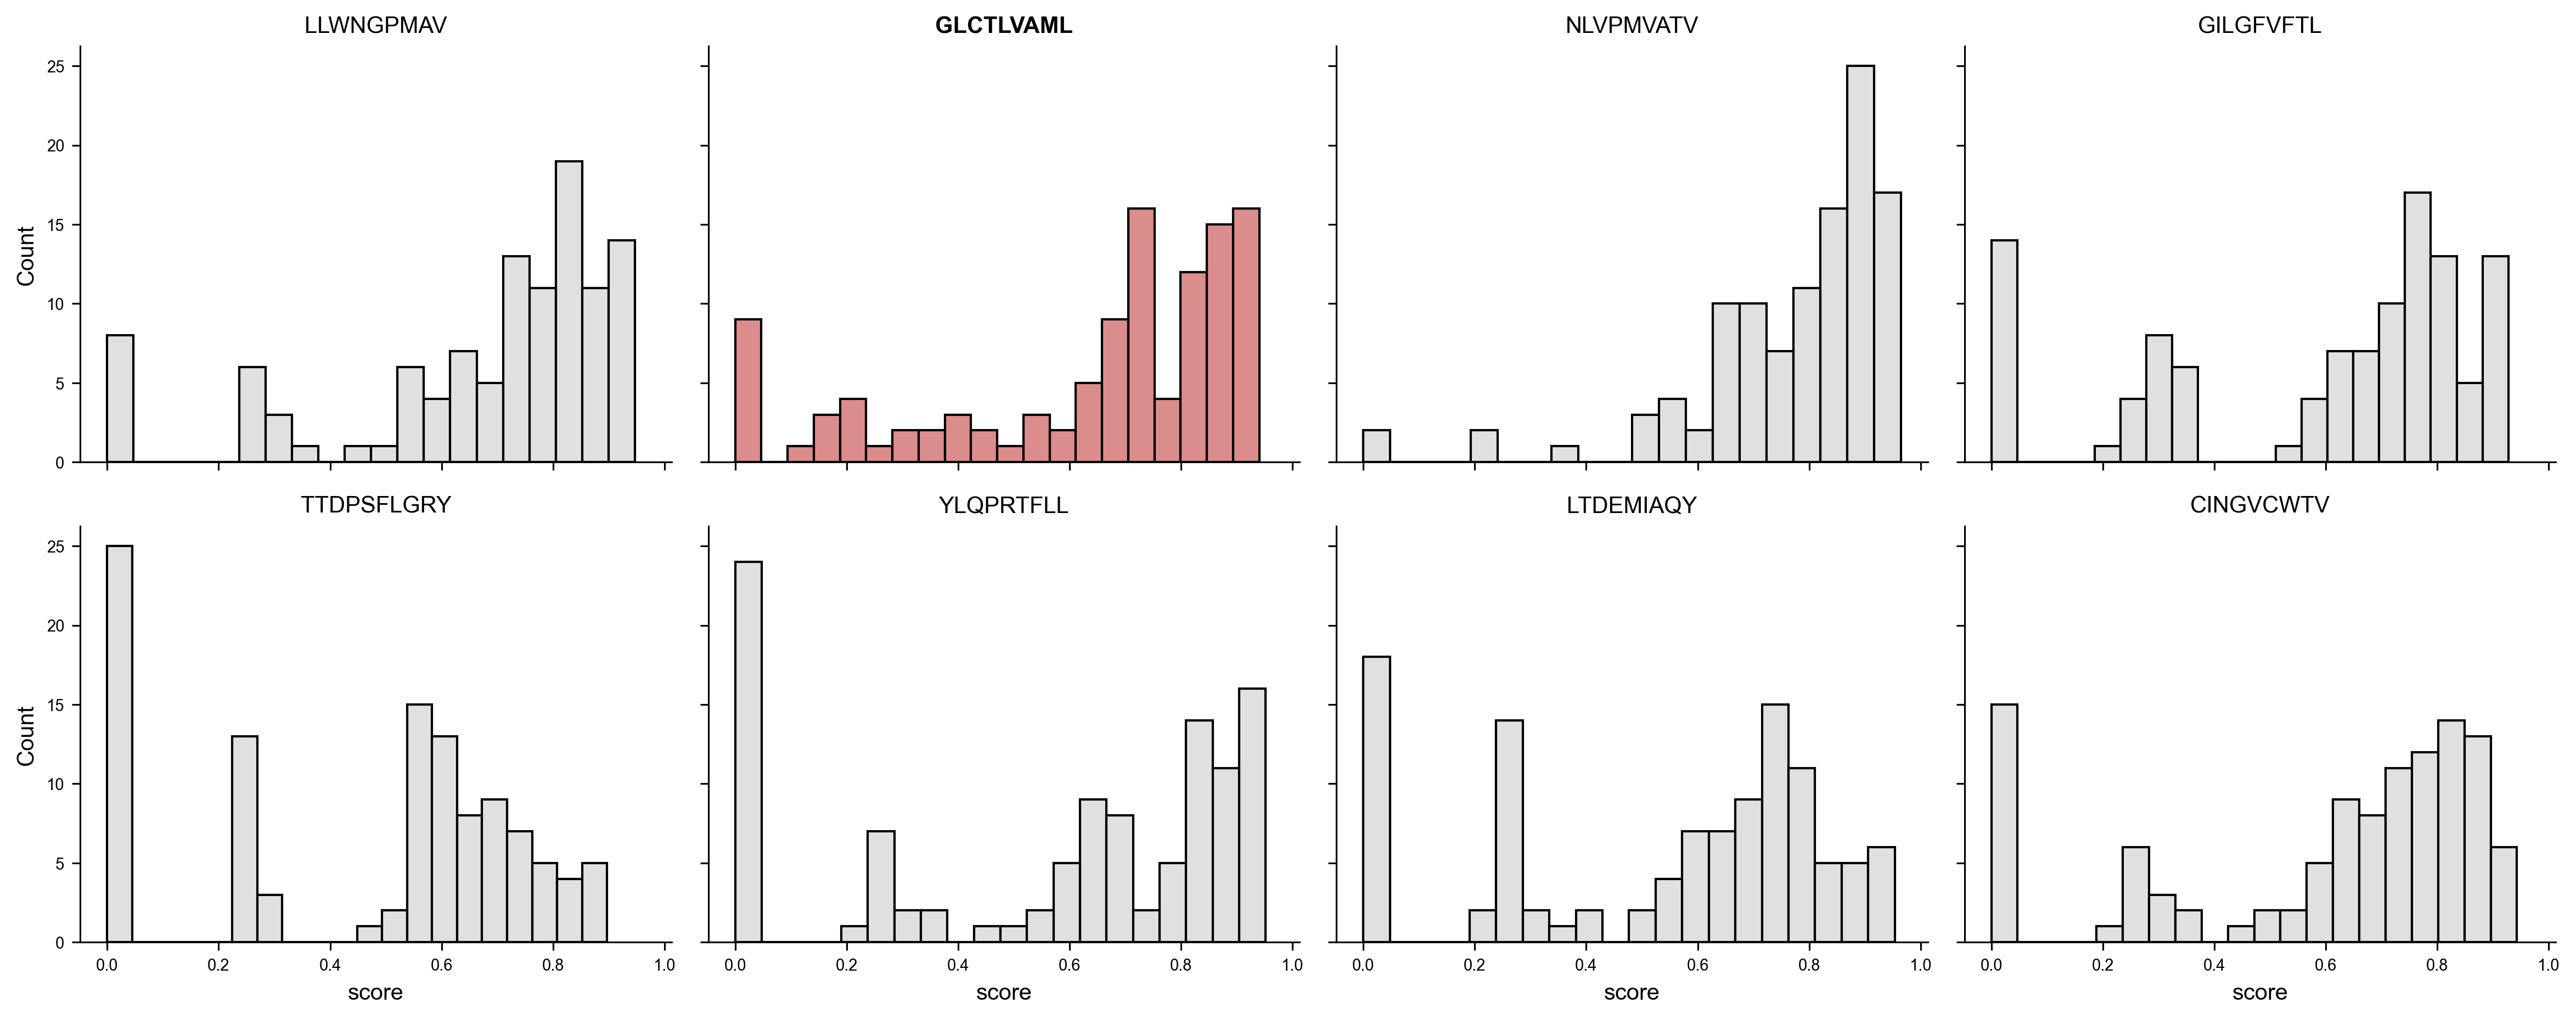

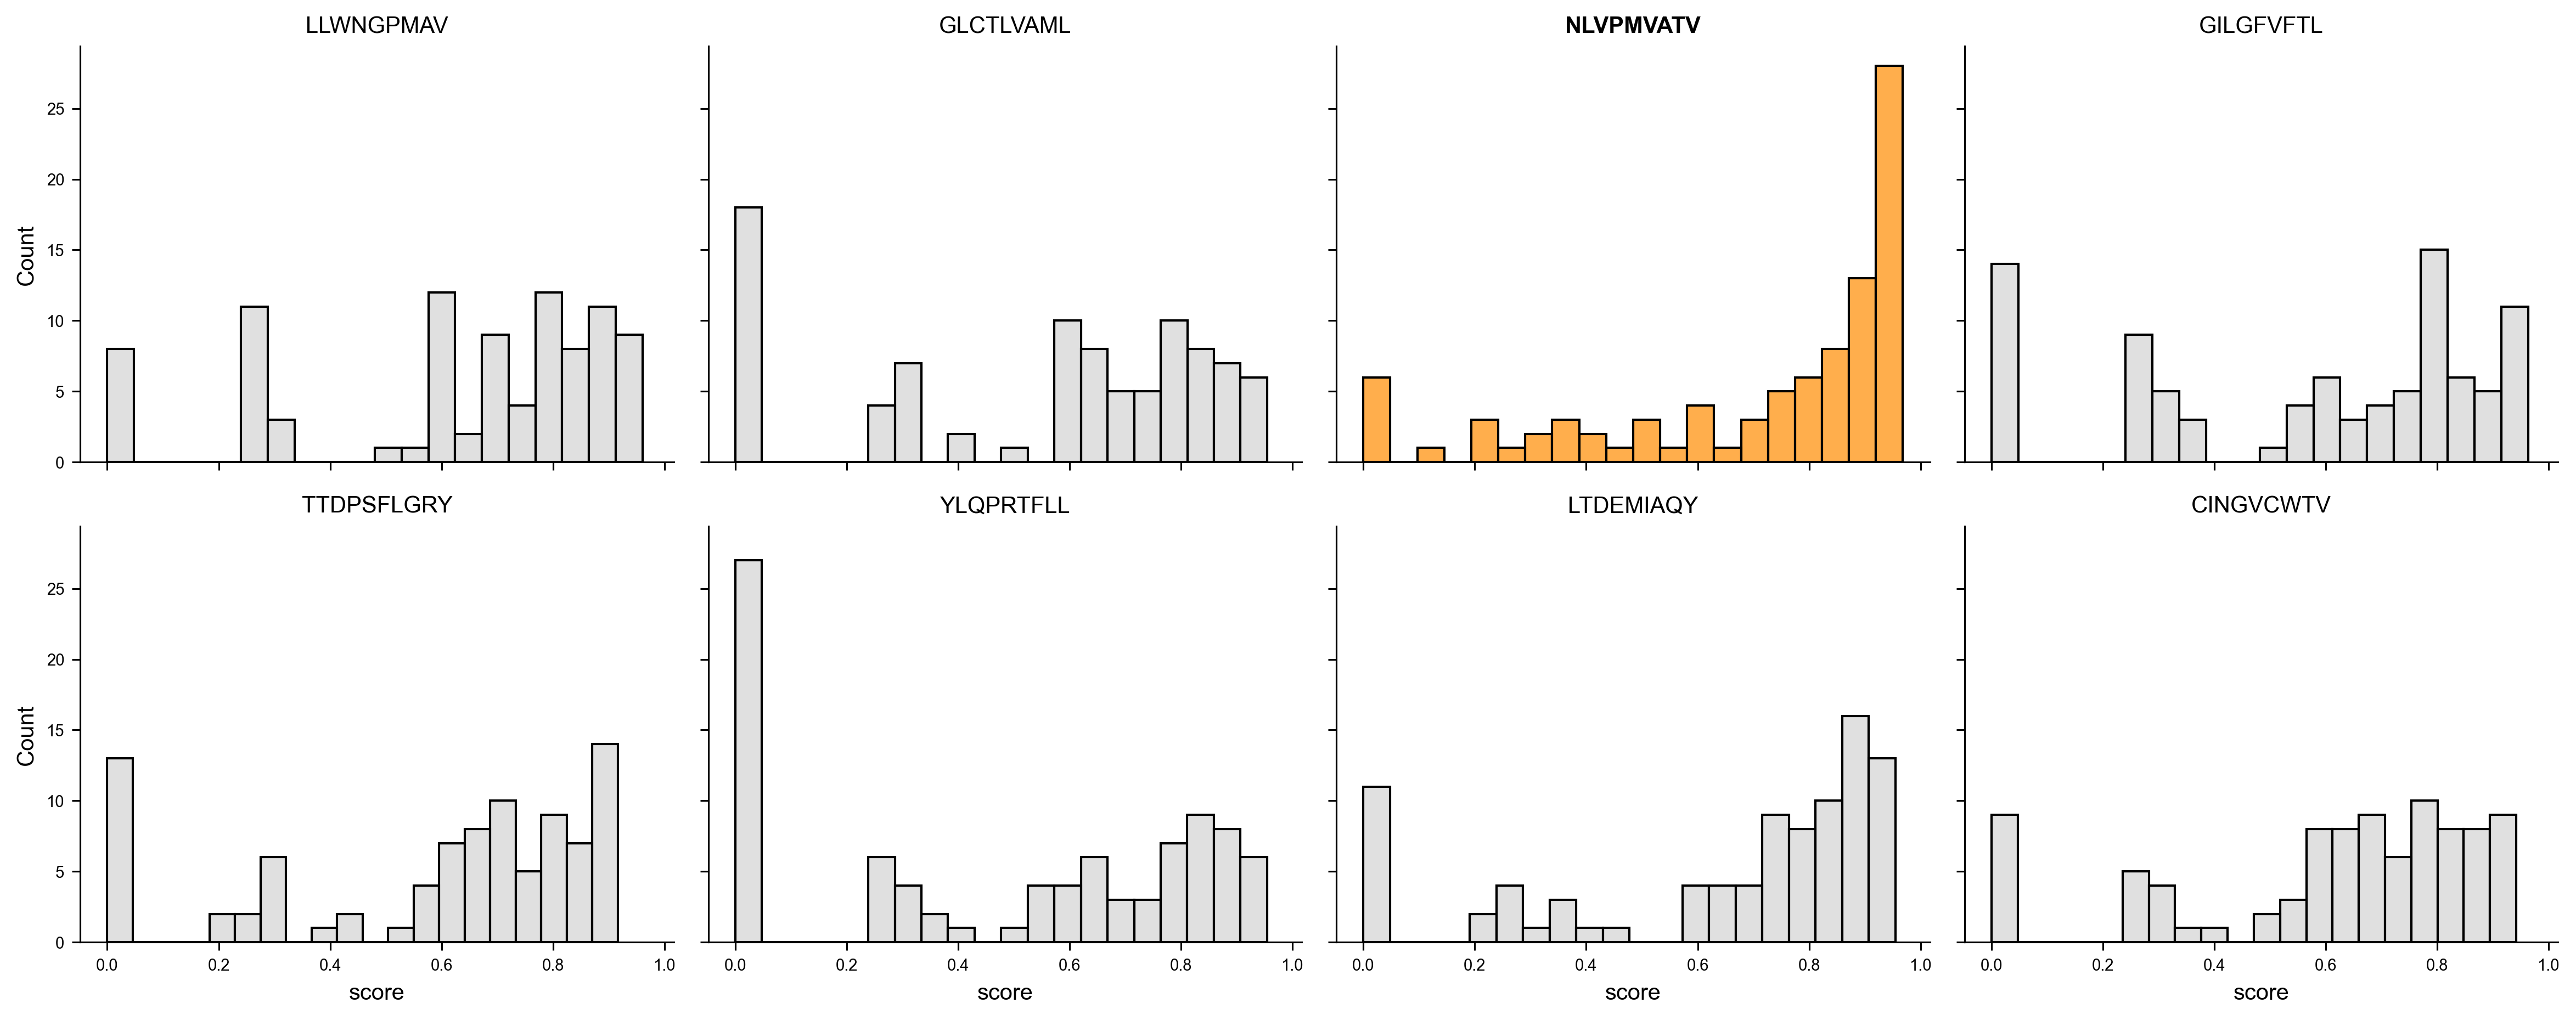

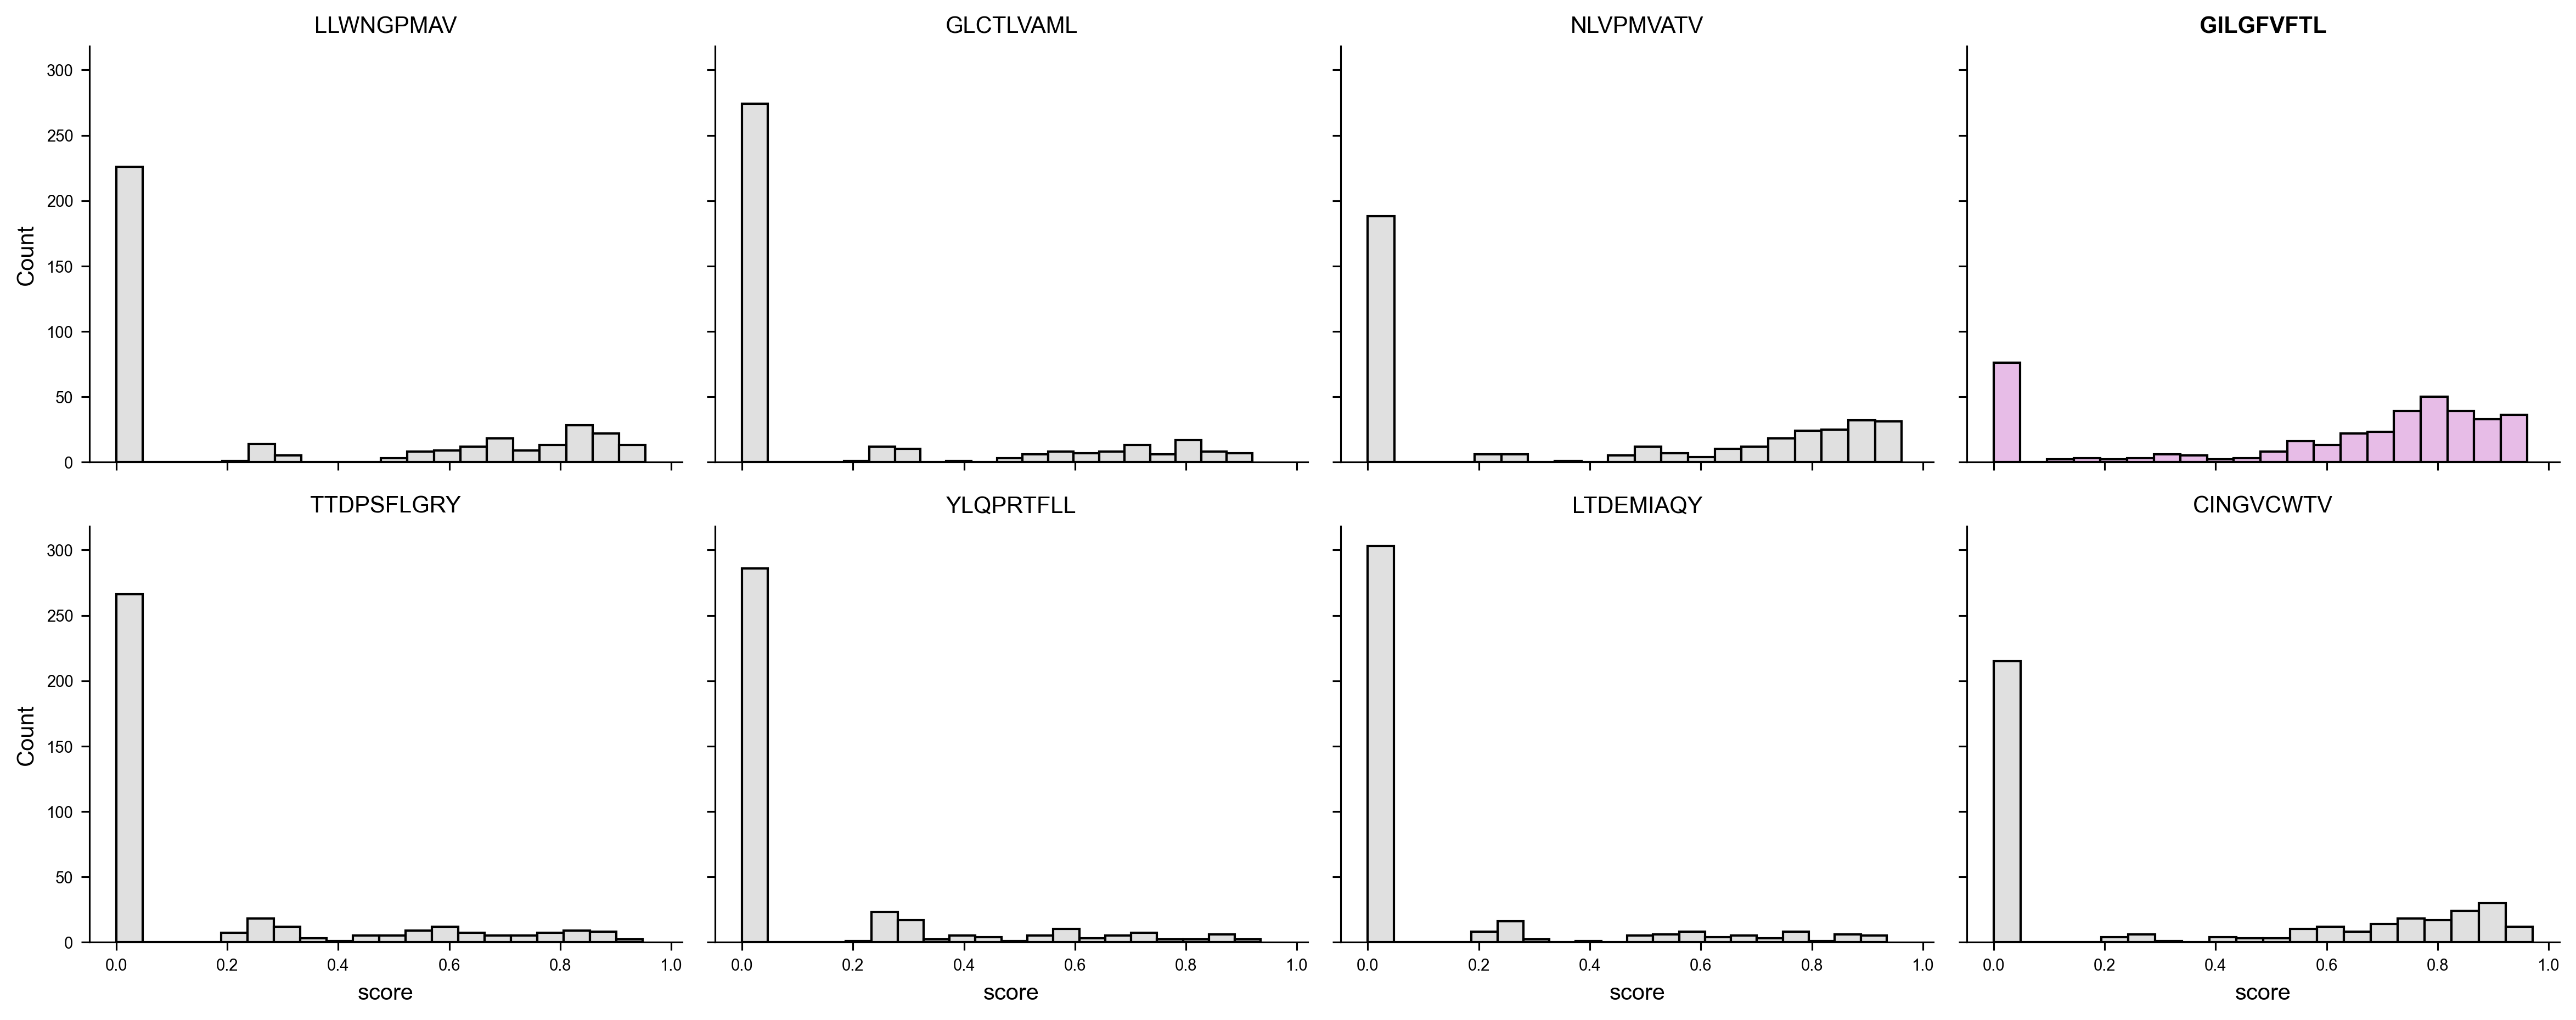

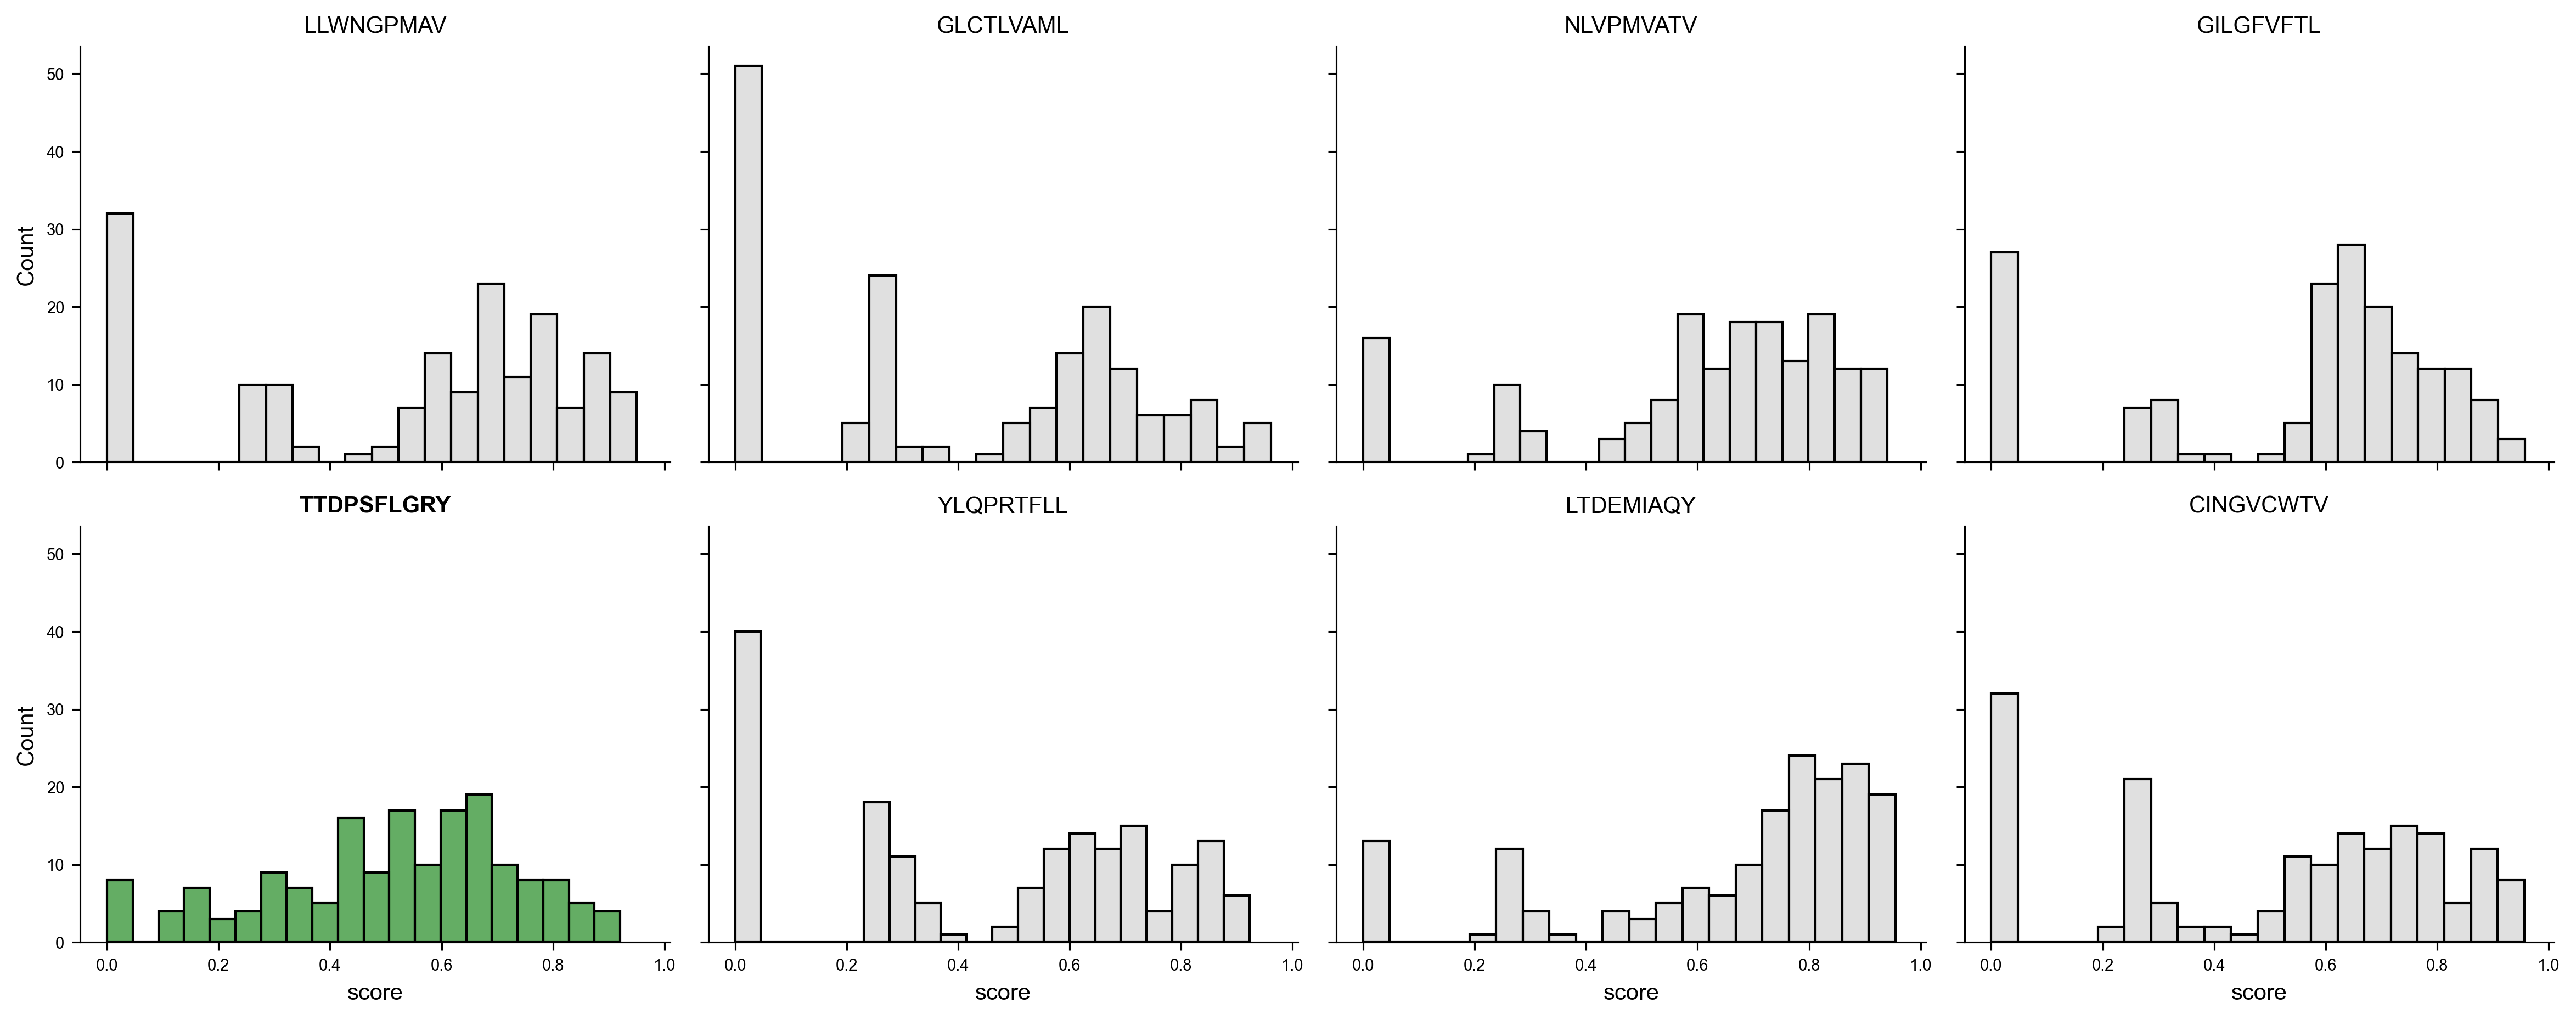

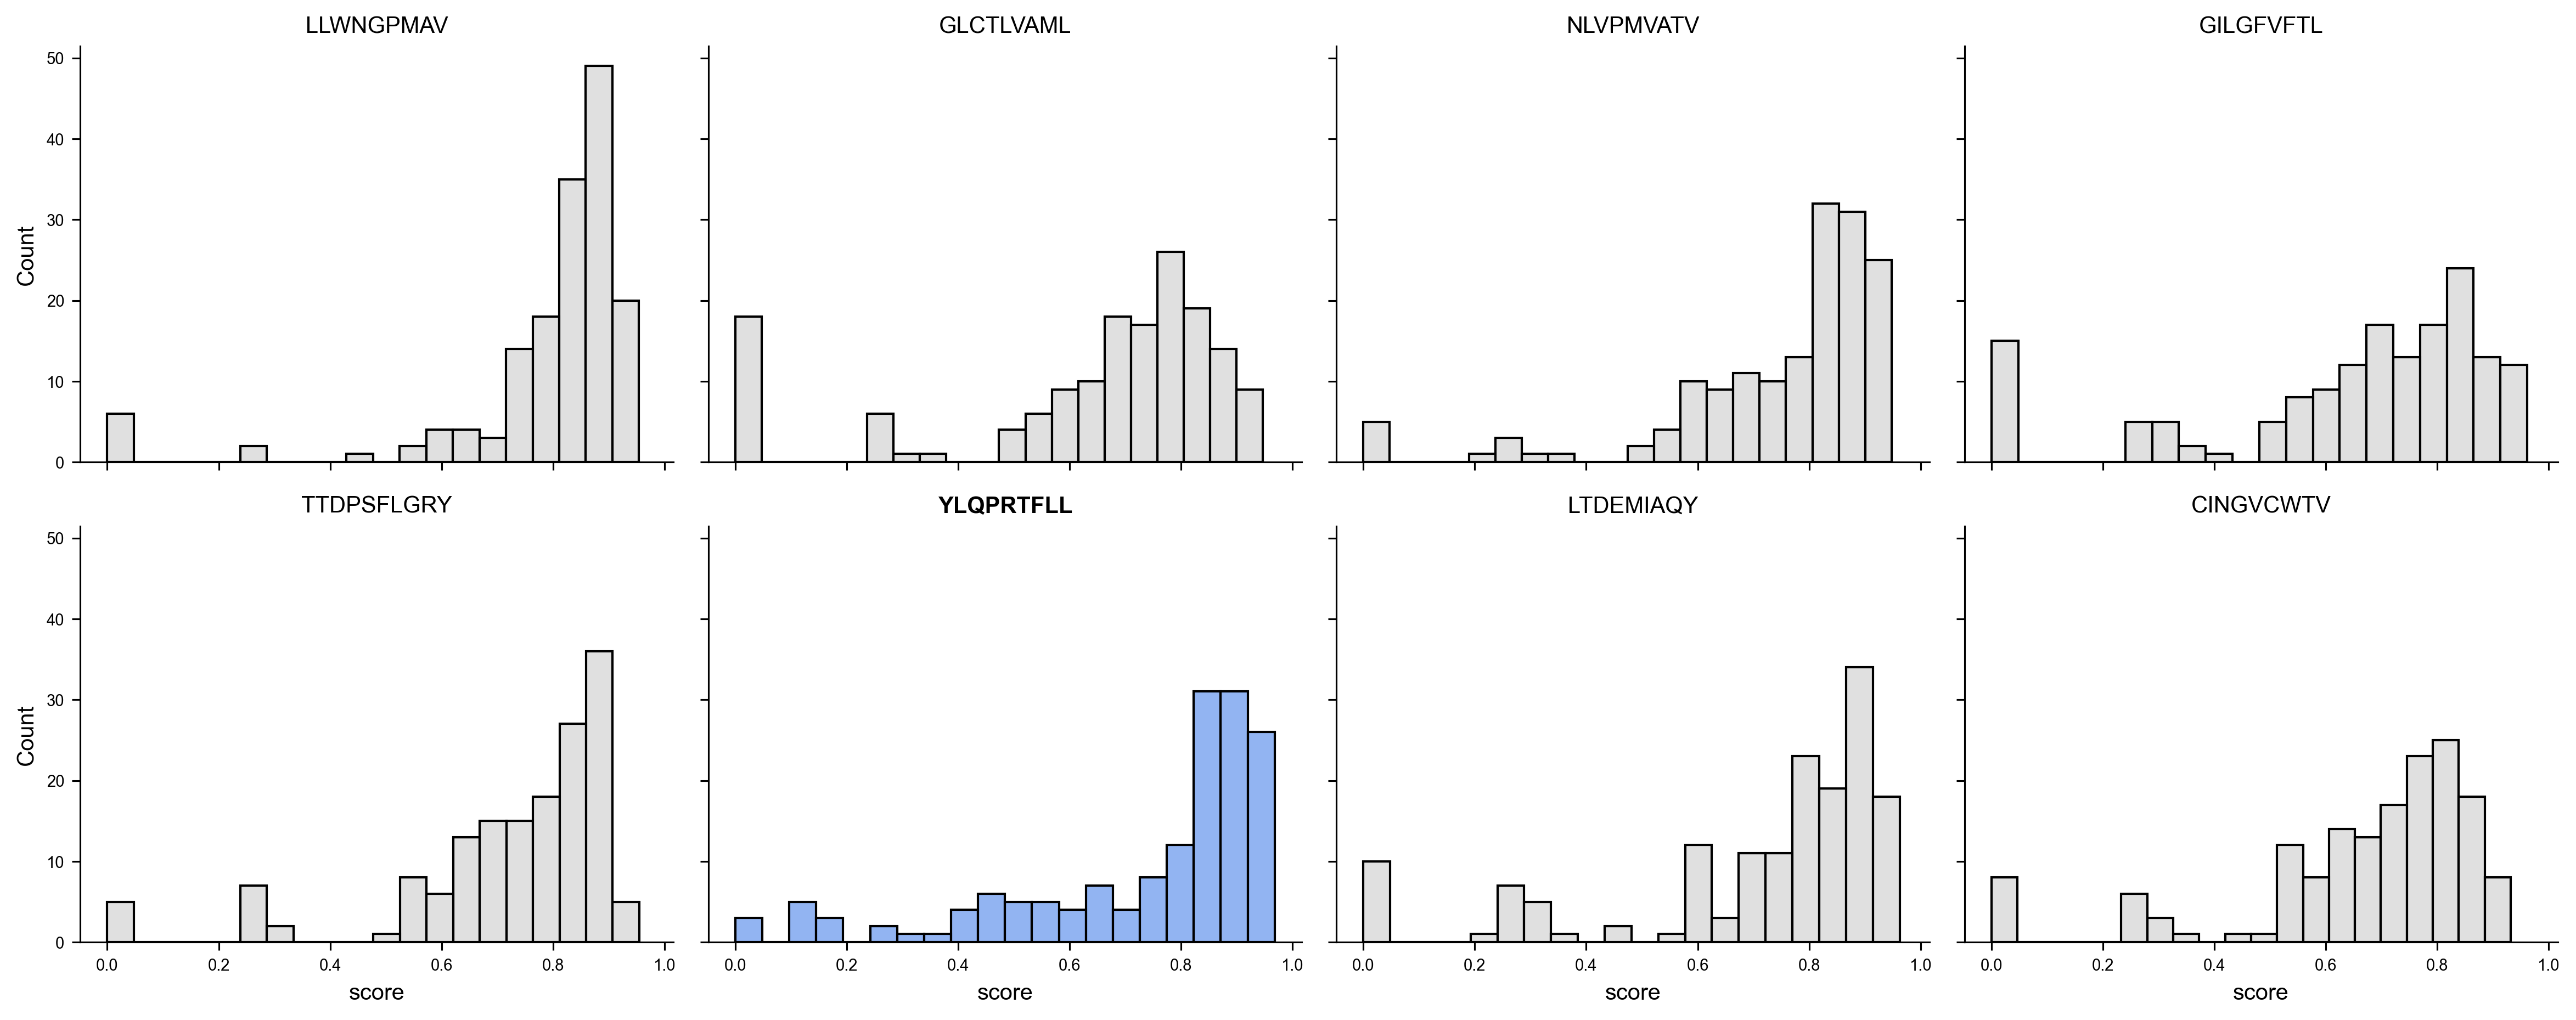

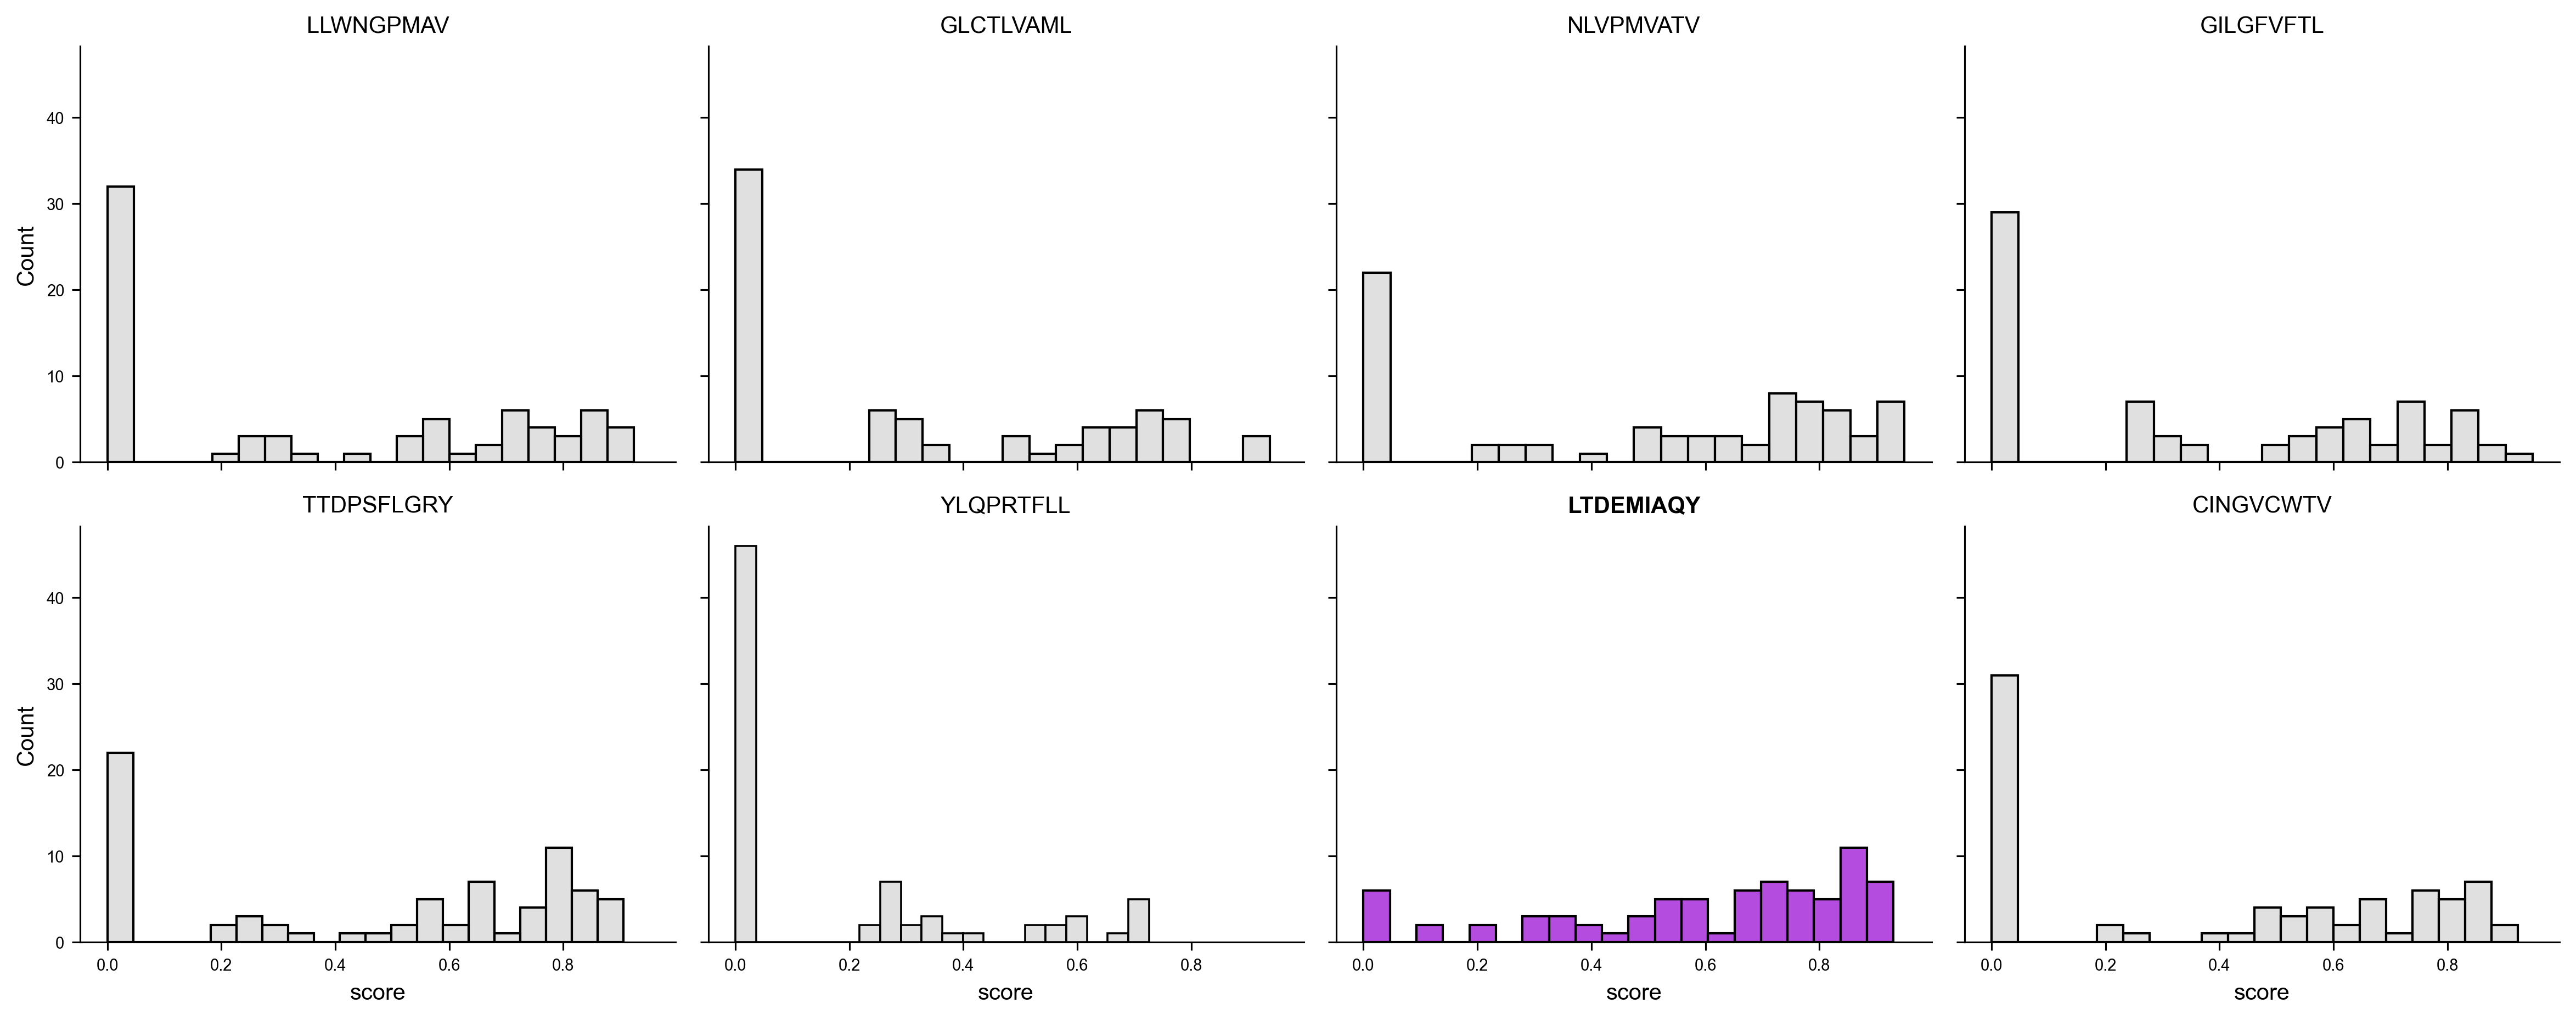

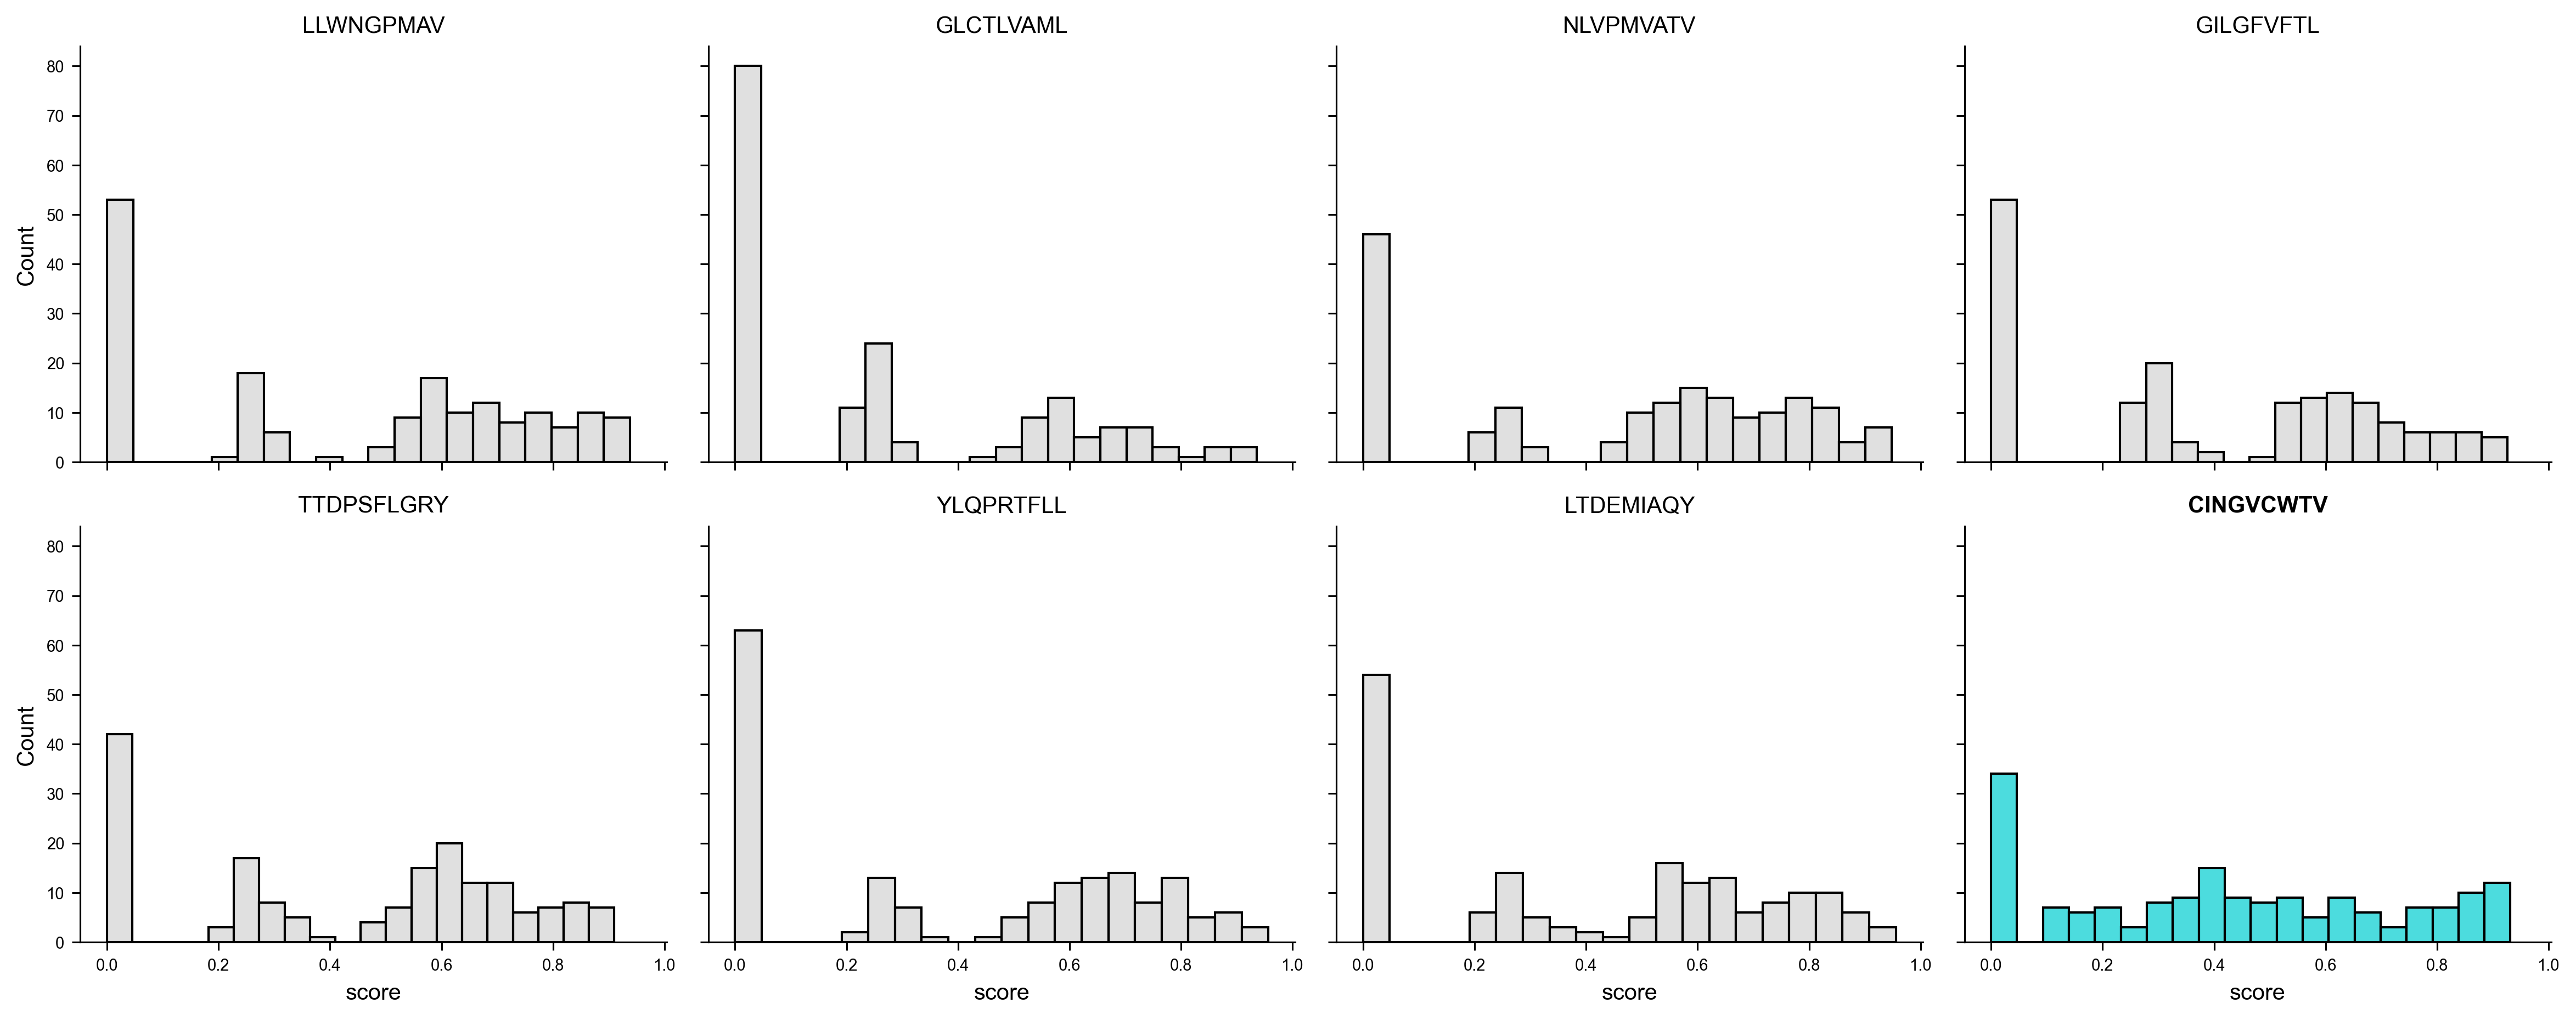

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

for epitope in all_epitope_preds.keys():
    subset_df = all_epitope_preds[epitope]
    melted = subset_df.melt(
        value_vars=[f"score_{e}" for e in all_epitope_preds.keys()],
        var_name="epitope_swapped", value_name="score"
    )
    melted["epitope_swapped"] = melted["epitope_swapped"].str.replace("score_", "")

    # Create FacetGrid (size 10/2.54, 8/2.54)
    g = sns.FacetGrid(melted, col="epitope_swapped", col_wrap=4, sharex=True, sharey=True, height=8/2.54, aspect=10/8)

    # Map histogram with color depending on cognate
    def hist_with_cognate_color(data, color, **kwargs):
        current_epitope = data["epitope_swapped"].iloc[0]
        bar_color = name_color_dict[current_epitope] if current_epitope == epitope else 'lightgrey'
        sns.histplot(data=data, x="score", bins=20, color=bar_color, alpha=0.7, **kwargs,)# fontsize=7)

    g.map_dataframe(hist_with_cognate_color)

    # Bold title for cognate subplot
    for ax in g.axes.flat:
        title = ax.get_title().replace("epitope_swapped = ", "")
        if title == epitope:
            ax.set_title(title, fontweight="bold", fontsize=10)
        else:
            ax.set_title(title, fontsize=10)

    plt.tight_layout()
    plt.savefig(out_path_dropbox + f'{epitope}-swap_histograms.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

In [ ]:
concatted_all_epitope_preds = pd.concat(all_epitope_preds.values()).reset_index(drop=True)

### plot performance


LLWNGPMAV
['score_LLWNGPMAV', 'score_GLCTLVAML', 'score_NLVPMVATV', 'score_GILGFVFTL', 'score_TTDPSFLGRY', 'score_YLQPRTFLL', 'score_LTDEMIAQY', 'score_CINGVCWTV']
Average precision score: 0.491, random: 0.123


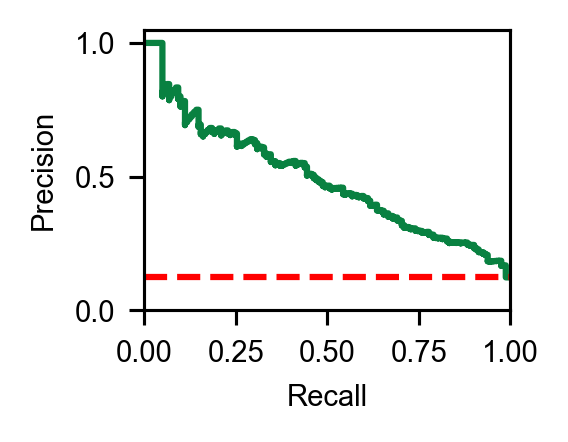

roc_auc 0.844
1321
162


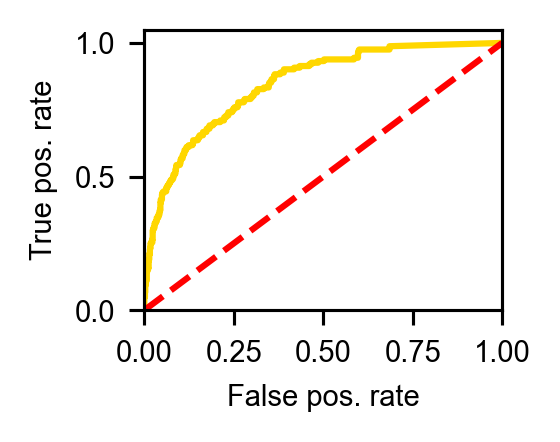


GLCTLVAML
['score_GLCTLVAML', 'score_LLWNGPMAV', 'score_NLVPMVATV', 'score_GILGFVFTL', 'score_TTDPSFLGRY', 'score_YLQPRTFLL', 'score_LTDEMIAQY', 'score_CINGVCWTV']
Average precision score: 0.163, random: 0.083


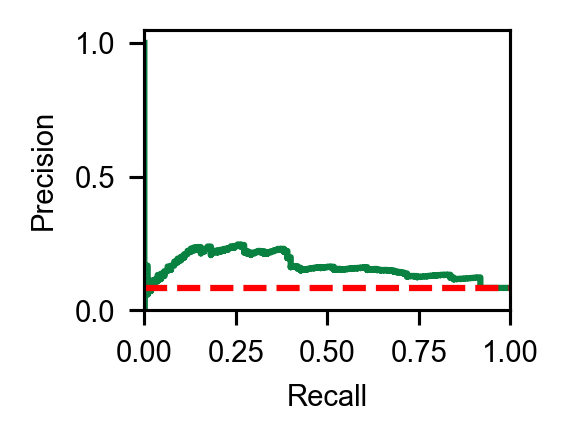

roc_auc 0.713
1321
110


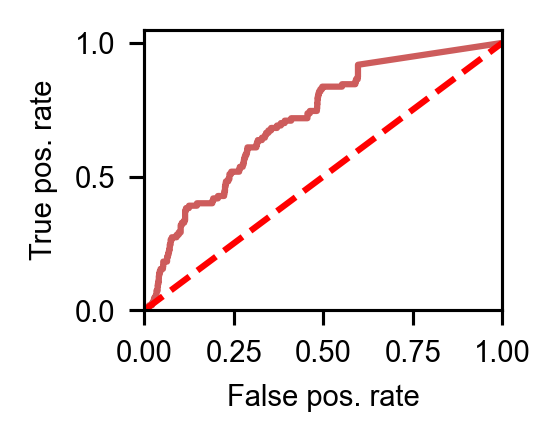


NLVPMVATV
['score_NLVPMVATV', 'score_LLWNGPMAV', 'score_GLCTLVAML', 'score_GILGFVFTL', 'score_TTDPSFLGRY', 'score_YLQPRTFLL', 'score_LTDEMIAQY', 'score_CINGVCWTV']
Average precision score: 0.185, random: 0.069


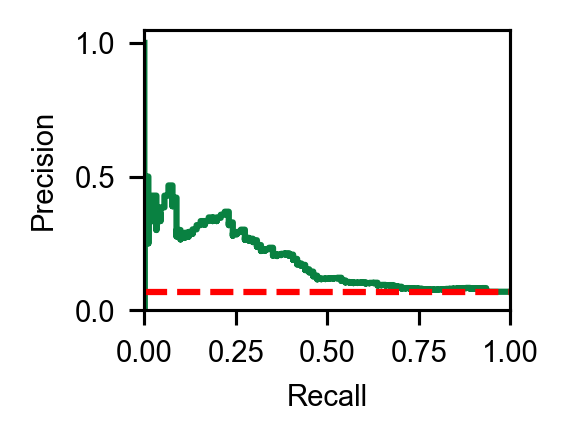

roc_auc 0.664
1321
91


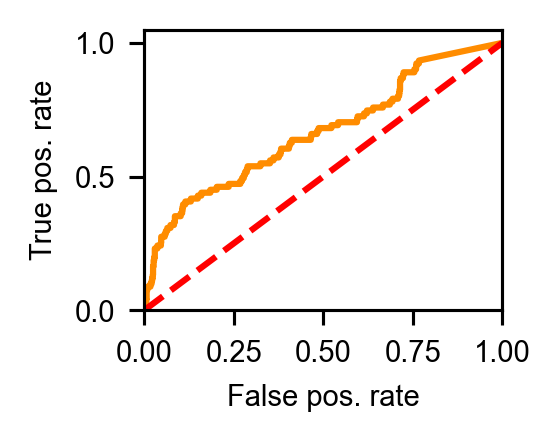


GILGFVFTL
['score_GILGFVFTL', 'score_LLWNGPMAV', 'score_GLCTLVAML', 'score_NLVPMVATV', 'score_TTDPSFLGRY', 'score_YLQPRTFLL', 'score_LTDEMIAQY', 'score_CINGVCWTV']
Average precision score: 0.341, random: 0.288


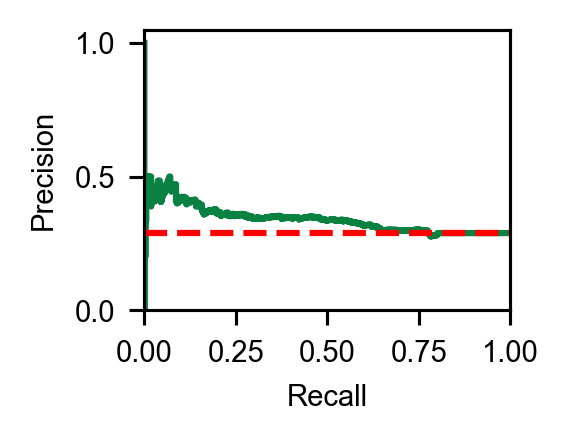

roc_auc 0.547
1321
381


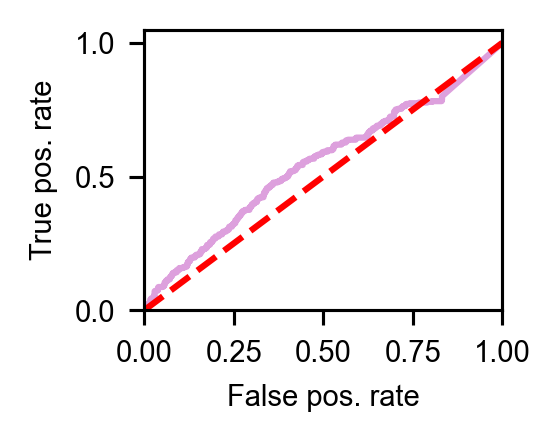


TTDPSFLGRY
['score_TTDPSFLGRY', 'score_LLWNGPMAV', 'score_GLCTLVAML', 'score_NLVPMVATV', 'score_GILGFVFTL', 'score_YLQPRTFLL', 'score_LTDEMIAQY', 'score_CINGVCWTV']
Average precision score: 0.124, random: 0.129


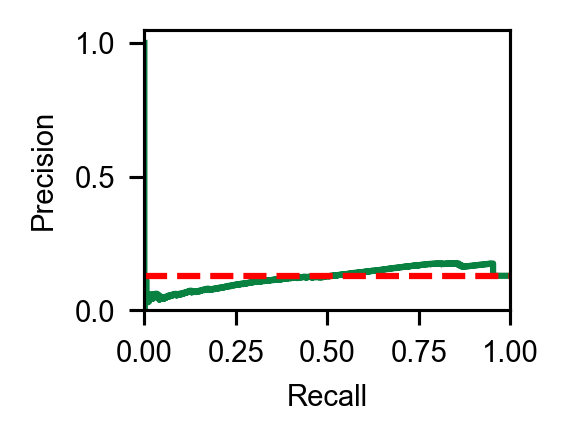

roc_auc 0.538
1321
170


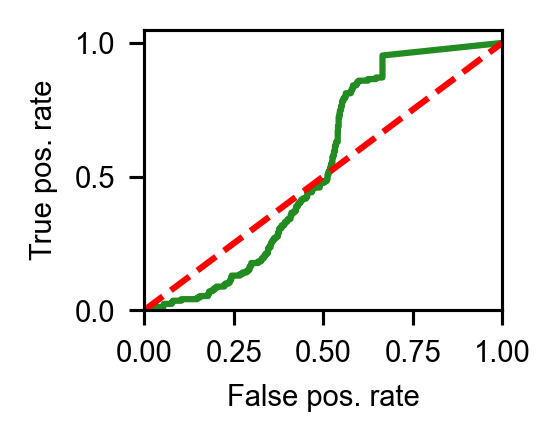


YLQPRTFLL
['score_YLQPRTFLL', 'score_LLWNGPMAV', 'score_GLCTLVAML', 'score_NLVPMVATV', 'score_GILGFVFTL', 'score_TTDPSFLGRY', 'score_LTDEMIAQY', 'score_CINGVCWTV']
Average precision score: 0.409, random: 0.120


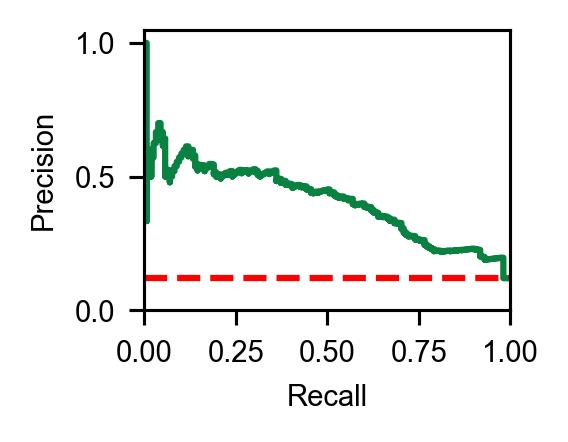

roc_auc 0.830
1321
158


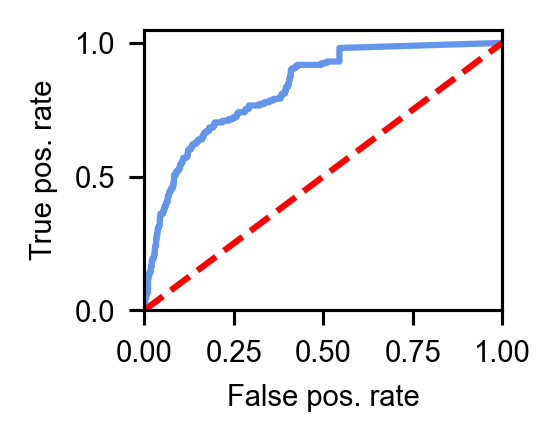


LTDEMIAQY
['score_LTDEMIAQY', 'score_LLWNGPMAV', 'score_GLCTLVAML', 'score_NLVPMVATV', 'score_GILGFVFTL', 'score_TTDPSFLGRY', 'score_YLQPRTFLL', 'score_CINGVCWTV']
Average precision score: 0.068, random: 0.057


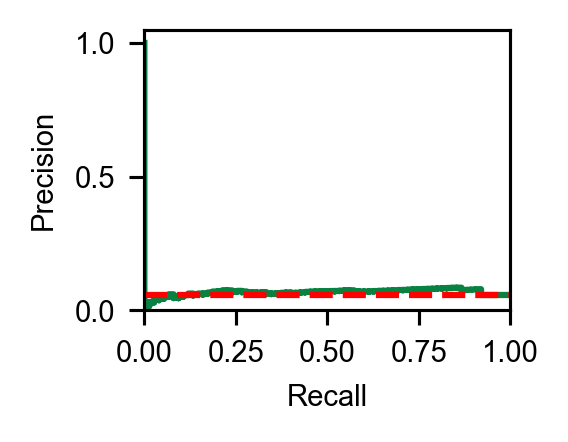

roc_auc 0.605
1321
75


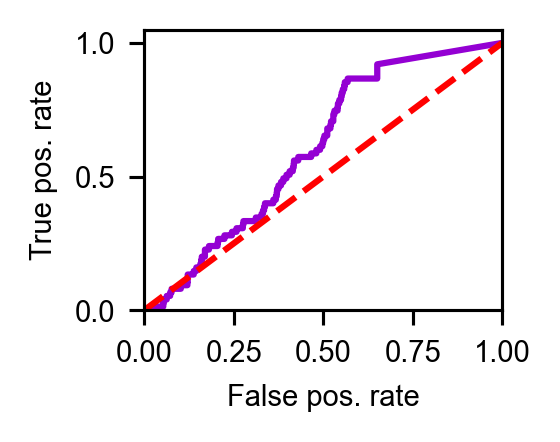


CINGVCWTV
['score_CINGVCWTV', 'score_LLWNGPMAV', 'score_GLCTLVAML', 'score_NLVPMVATV', 'score_GILGFVFTL', 'score_TTDPSFLGRY', 'score_YLQPRTFLL', 'score_LTDEMIAQY']
Average precision score: 0.109, random: 0.132


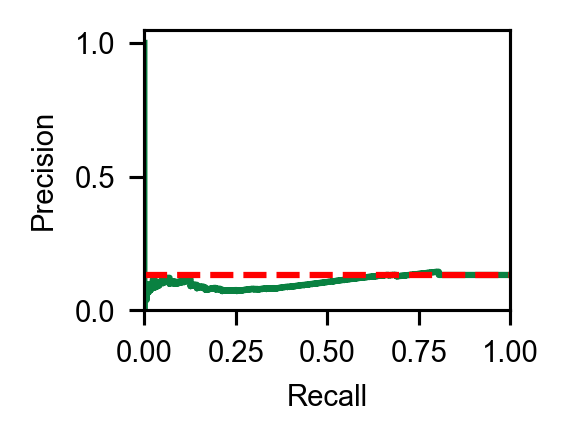

roc_auc 0.422
1321
174


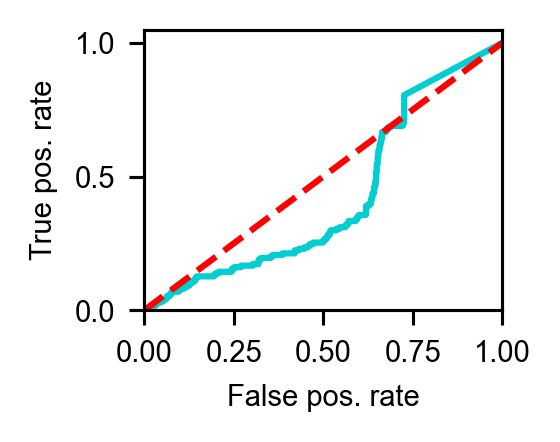


LLWNGPMAV
['score_LLWNGPMAV', 'score_GLCTLVAML', 'score_NLVPMVATV', 'score_GILGFVFTL', 'score_TTDPSFLGRY', 'score_YLQPRTFLL', 'score_LTDEMIAQY', 'score_CINGVCWTV']
Average precision score: 0.178, random: 0.123


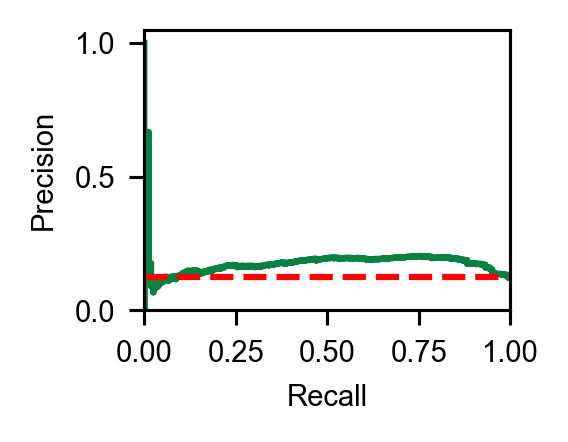

roc_auc 0.674
1321
162


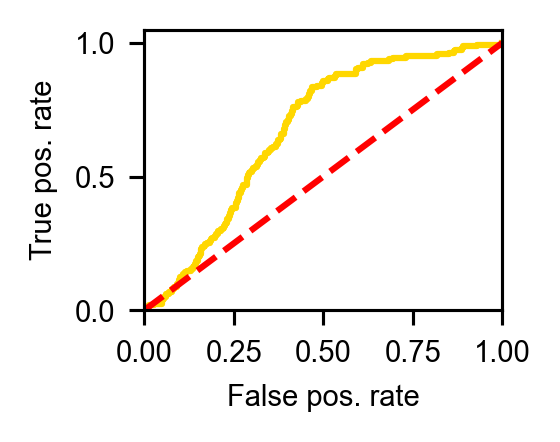


GLCTLVAML
['score_GLCTLVAML', 'score_LLWNGPMAV', 'score_NLVPMVATV', 'score_GILGFVFTL', 'score_TTDPSFLGRY', 'score_YLQPRTFLL', 'score_LTDEMIAQY', 'score_CINGVCWTV']
Average precision score: 0.200, random: 0.083


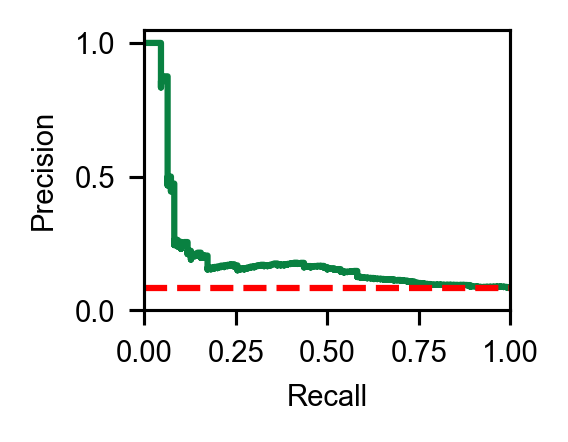

roc_auc 0.645
1321
110


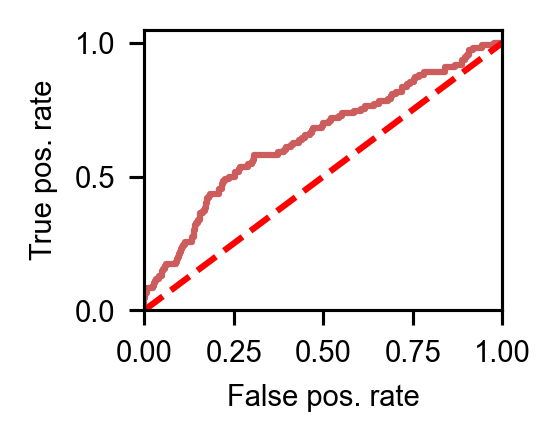


NLVPMVATV
['score_NLVPMVATV', 'score_LLWNGPMAV', 'score_GLCTLVAML', 'score_GILGFVFTL', 'score_TTDPSFLGRY', 'score_YLQPRTFLL', 'score_LTDEMIAQY', 'score_CINGVCWTV']
Average precision score: 0.085, random: 0.069


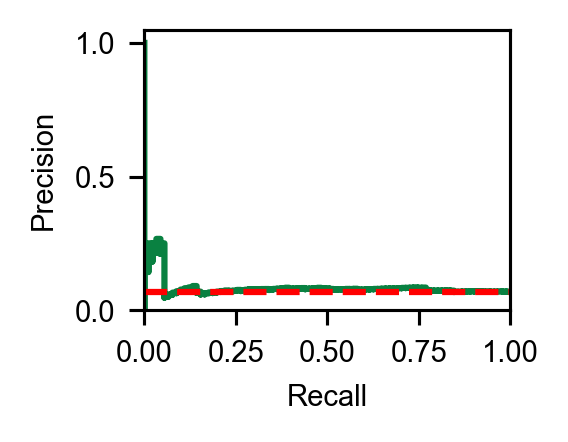

roc_auc 0.545
1321
91


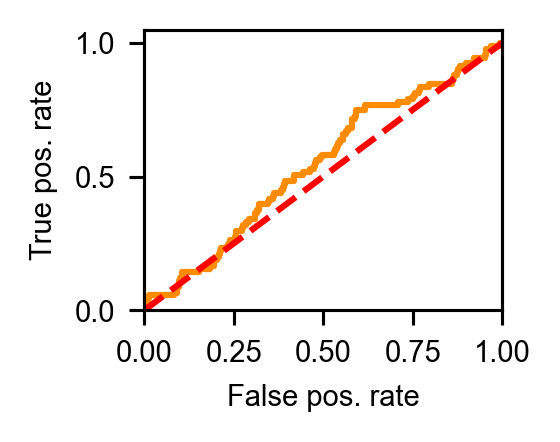


GILGFVFTL
['score_GILGFVFTL', 'score_LLWNGPMAV', 'score_GLCTLVAML', 'score_NLVPMVATV', 'score_TTDPSFLGRY', 'score_YLQPRTFLL', 'score_LTDEMIAQY', 'score_CINGVCWTV']
Average precision score: 0.765, random: 0.288


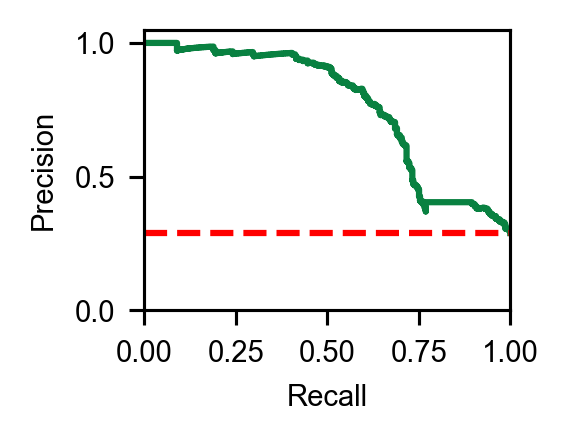

roc_auc 0.821
1321
381


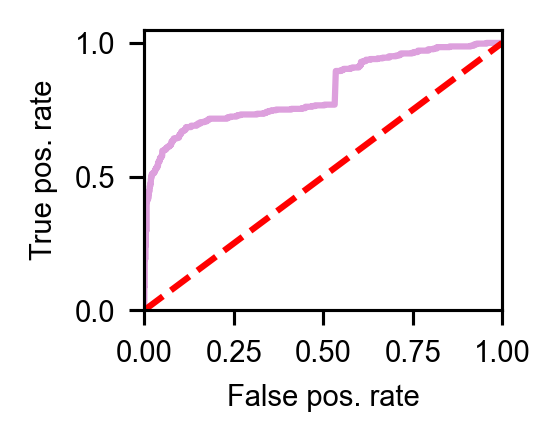


TTDPSFLGRY
['score_TTDPSFLGRY', 'score_LLWNGPMAV', 'score_GLCTLVAML', 'score_NLVPMVATV', 'score_GILGFVFTL', 'score_YLQPRTFLL', 'score_LTDEMIAQY', 'score_CINGVCWTV']
Average precision score: 0.133, random: 0.129


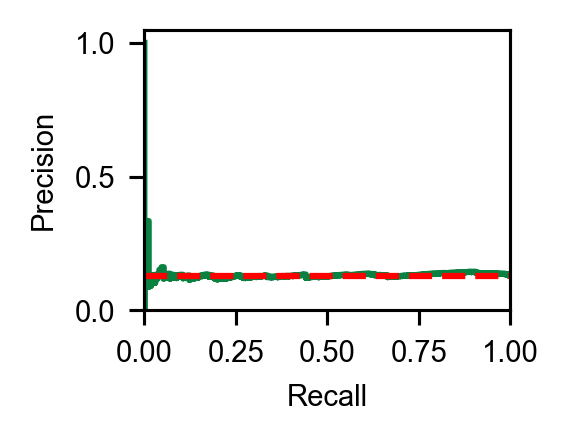

roc_auc 0.515
1321
170


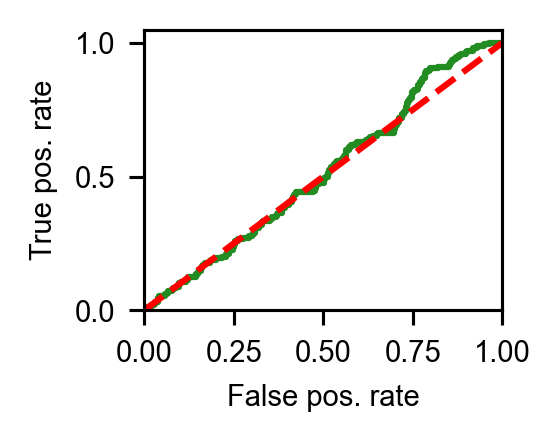


YLQPRTFLL
['score_YLQPRTFLL', 'score_LLWNGPMAV', 'score_GLCTLVAML', 'score_NLVPMVATV', 'score_GILGFVFTL', 'score_TTDPSFLGRY', 'score_LTDEMIAQY', 'score_CINGVCWTV']
Average precision score: 0.193, random: 0.120


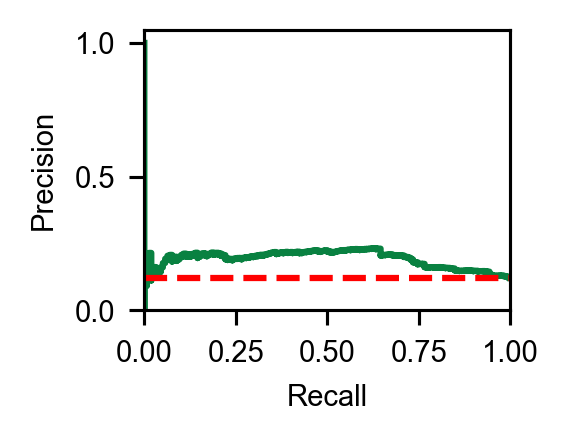

roc_auc 0.682
1321
158


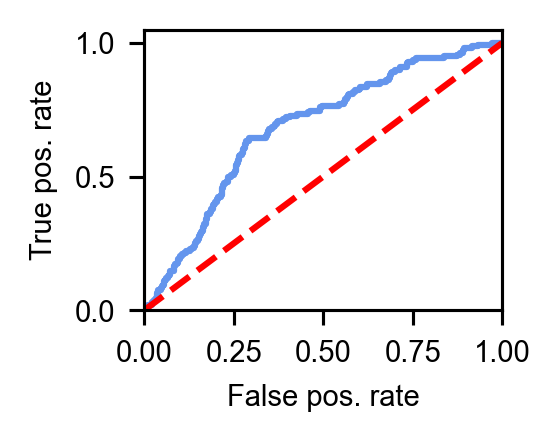


LTDEMIAQY
['score_LTDEMIAQY', 'score_LLWNGPMAV', 'score_GLCTLVAML', 'score_NLVPMVATV', 'score_GILGFVFTL', 'score_TTDPSFLGRY', 'score_YLQPRTFLL', 'score_CINGVCWTV']
Average precision score: 0.229, random: 0.057


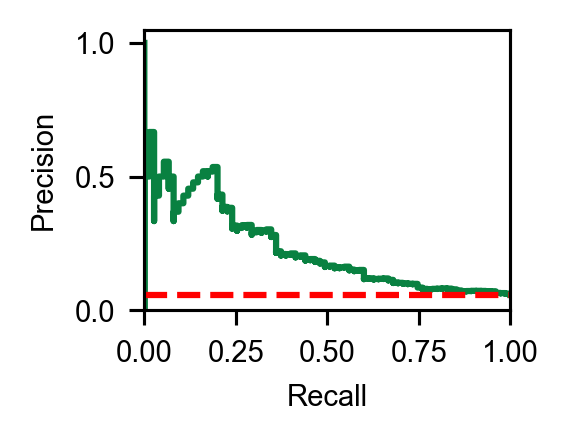

roc_auc 0.740
1321
75


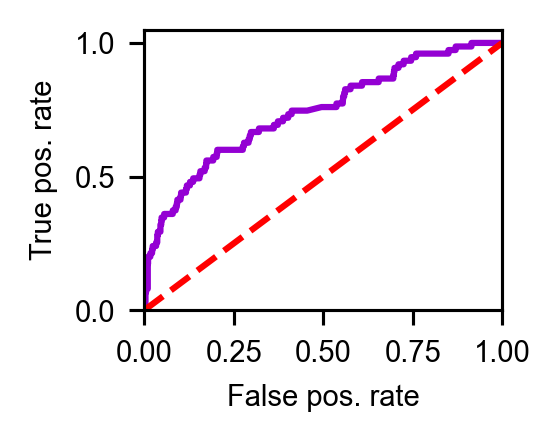


CINGVCWTV
['score_CINGVCWTV', 'score_LLWNGPMAV', 'score_GLCTLVAML', 'score_NLVPMVATV', 'score_GILGFVFTL', 'score_TTDPSFLGRY', 'score_YLQPRTFLL', 'score_LTDEMIAQY']
Average precision score: 0.158, random: 0.132


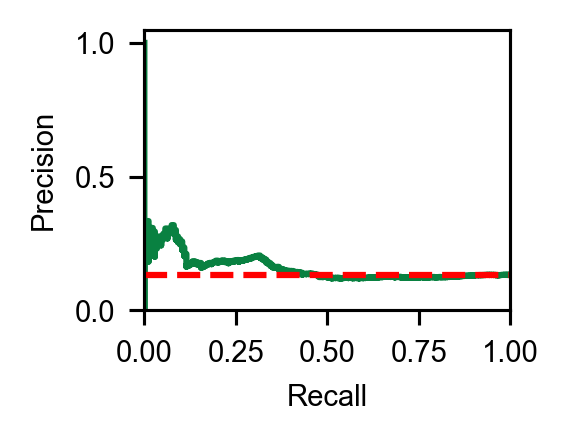

roc_auc 0.503
1321
174


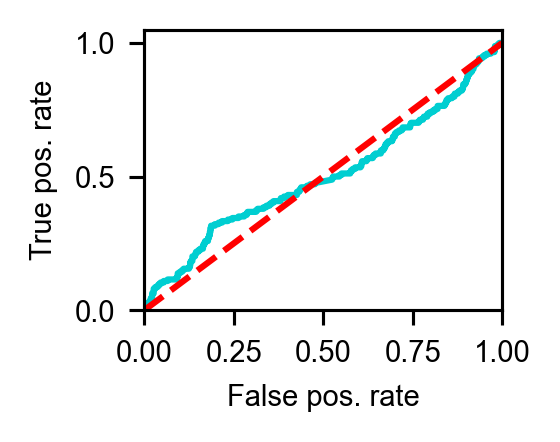

In [24]:
linewidth = mylines
concatted_all_epitope_preds_with_closeness = concatted_all_epitope_preds.copy()
concatted_all_epitope_preds_with_closeness['cognate_closeness'] = None

n_epi = len(all_epitopes_for_swap)
for with_without_alignment in [False,True]:
    all_closeness_scores = {}
    for epitope in all_epitopes_for_swap:
        print()
        print(epitope)

        all_score_cols = [f"score_{e}" for e in all_epitope_preds.keys()]
        cols_ordered = [f"score_{epitope}"] + [c for c in all_score_cols if c != f"score_{epitope}"]
        subset_df = concatted_all_epitope_preds.copy()
        points = subset_df[cols_ordered].to_numpy()
        if with_without_alignment:
            vec = np.zeros(n_epi)
            vec[0] = 1
            for v in range(1,n_epi):
                vec[v] = -1/(n_epi-1)
            vec = vec / np.linalg.norm(vec)

            closeness_all = points @ vec  
           
        else:
            closeness_all = subset_df[f'score_{epitope}'].to_numpy()

        label = [1 if epi == epitope else 0 for epi in subset_df['epitope_cognate']]
        all_closeness_scores[epitope] = {
            'ids': subset_df['tcr_id'].tolist(),
            'closeness': closeness_all.tolist(),
            'labels': label,
        }

        concatted_all_epitope_preds_with_closeness.loc[concatted_all_epitope_preds_with_closeness['epitope_cognate'] == epitope, 'cognate_closeness'] = closeness_all[[i for i, epi in enumerate(subset_df['epitope_cognate']) if epi == epitope]]

        print(cols_ordered)
        # print(vec)

        from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score, roc_curve

        precision, recall, _ = precision_recall_curve(label, closeness_all)
        average_precision = average_precision_score(label, closeness_all)
        random_performance = sum(label) / len(label)
        print(f'Average precision score: {average_precision:.3f}, random: {random_performance:.3f}')
        plt.figure(figsize=figsize_prc_auc) 
        plt.step(recall, precision, alpha=1, where='post', label=f'AF3-ABi ({average_precision:.2f} AP)', color=color_dict['AF3'], )
        plt.axhline(y=random_performance, color='r', linestyle='--', label=f'Random ({random_performance:.2f} AP)')
        plt.xlabel('Recall', fontsize=fontsize_axes)
        plt.ylabel('Precision', fontsize=fontsize_axes)
        plt.ylim(0, 1.05)
        plt.xlim(0, 1.0)
        plt.show()
        plt.close()

        # auc 
        roc_auc = roc_auc_score(label, closeness_all)
        print(f'roc_auc {roc_auc:.3f}')
        print(len(closeness_all))
        print(sum(label))
        fpr, tpr, _ = roc_curve(label, closeness_all)
        plt.figure(figsize=figsize_prc_auc)
        plt.plot(fpr, tpr, alpha=1, label=f'AF3-ABi ({roc_auc:.2f} AUC)', color=name_color_dict[epitope])
        plt.plot([0, 1], [0, 1], color='r', linestyle='--', label=f'Random (0.50 AUC)')
        plt.xlabel('False pos. rate', fontsize=fontsize_axes)
        plt.ylabel('True pos. rate', fontsize=fontsize_axes)
        plt.ylim(0, 1.05)
        plt.xlim(0, 1.0)
        # if SAVE_FIGS:
        if with_without_alignment:
            plt.savefig(out_path_dropbox + f'{epitope}-swap_auc_closeness.pdf', dpi=300, bbox_inches='tight')
        else:
            plt.savefig(out_path_dropbox + f'{epitope}-swap_auc_closeness_no_alignment.pdf', dpi=300, bbox_inches='tight')
        # plt.savefig("/Users/b.kwee/schumacher_lab Dropbox/schumi/ts/ts6_STAPLER_TCRs_top-10-epitopes_validation/publication/figures/v2/bjorn_v2/swap/" + f'{epitope}-swap_auc_closeness.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

### PDB structures before alphafold training cut-off

In [26]:
# 1OGA	2vlj	2vlr	5e6i	5euo	5isz	5jhd	5tez
# 1_3_B23_118_GILGFVFTL	1_3_B23_118_GILGFVFTL	1_4_G11_82_GILGFVFTL	1_4_C3_26_GILGFVFTL	1_4_G10_81_GILGFVFTL	1_4_G9_80_GILGFVFTL	1_4_G8_79_GILGFVFTL	1_4_C4_27_GILGFVFTL

pdb_to_tcrname = {
    '1OGA': '1_3_B23_118_GILGFVFTL',
    '2vlj': '1_3_B23_118_GILGFVFTL',
    '2vlr': '1_4_G11_82_GILGFVFTL',
    '5e6i': '1_4_C3_26_GILGFVFTL',
    '5euo': '1_4_G10_81_GILGFVFTL',
    '5isz': '1_4_G9_80_GILGFVFTL',
    '5jhd': '1_4_G8_79_GILGFVFTL',
    '5tez': '1_4_C4_27_GILGFVFTL',
}

# 3GSN	5d2l	5d2n
# 2_10_A10_9_NLVPMVATV	2_10_B8_19_NLVPMVATV	2_10_B4_15_NLVPMVATV
pdb_to_tcrname.update({
    '3GSN': '2_10_A10_9_NLVPMVATV',
    '5d2l': '2_10_B8_19_NLVPMVATV',
    '5d2n': '2_10_B4_15_NLVPMVATV',
})

# 3o4l
# 2_16_G10_81_GLCTLVAML
pdb_to_tcrname.update({
    '3o4l': '2_16_G10_81_GLCTLVAML',
})

# 7n1f	7n6e
# 1_7_A10_9_YLQPRTFLL	1_6_G13_168_YLQPRTFLL
pdb_to_tcrname.update({
    '7n1f': '1_7_A10_9_YLQPRTFLL',
    '7n6e': '1_6_G13_168_YLQPRTFLL',
})


pdb_to_tcrname = {k.upper(): v.upper() for k, v in pdb_to_tcrname.items()}
tcr_with_pdb = list(set(list(pdb_to_tcrname.values())))
tcr_with_pdb

['1_3_B23_118_GILGFVFTL',
 '1_4_C4_27_GILGFVFTL',
 '2_10_B8_19_NLVPMVATV',
 '2_10_B4_15_NLVPMVATV',
 '1_4_G11_82_GILGFVFTL',
 '2_10_A10_9_NLVPMVATV',
 '1_6_G13_168_YLQPRTFLL',
 '1_4_G8_79_GILGFVFTL',
 '1_4_G9_80_GILGFVFTL',
 '2_16_G10_81_GLCTLVAML',
 '1_4_C3_26_GILGFVFTL',
 '1_7_A10_9_YLQPRTFLL',
 '1_4_G10_81_GILGFVFTL']

### plot scores

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['5.1e-74', '5.0e-12', '3.8e-13', '2.0e-12', '6.9e-07', '2.0e-01', '6.1e-01', '8.9e-01']
381 GILGFVFTL
75 LTDEMIAQY
158 YLQPRTFLL
162 LLWNGPMAV
110 GLCTLVAML
91 NLVPMVATV
170 TTDPSFLGRY
174 CINGVCWTV


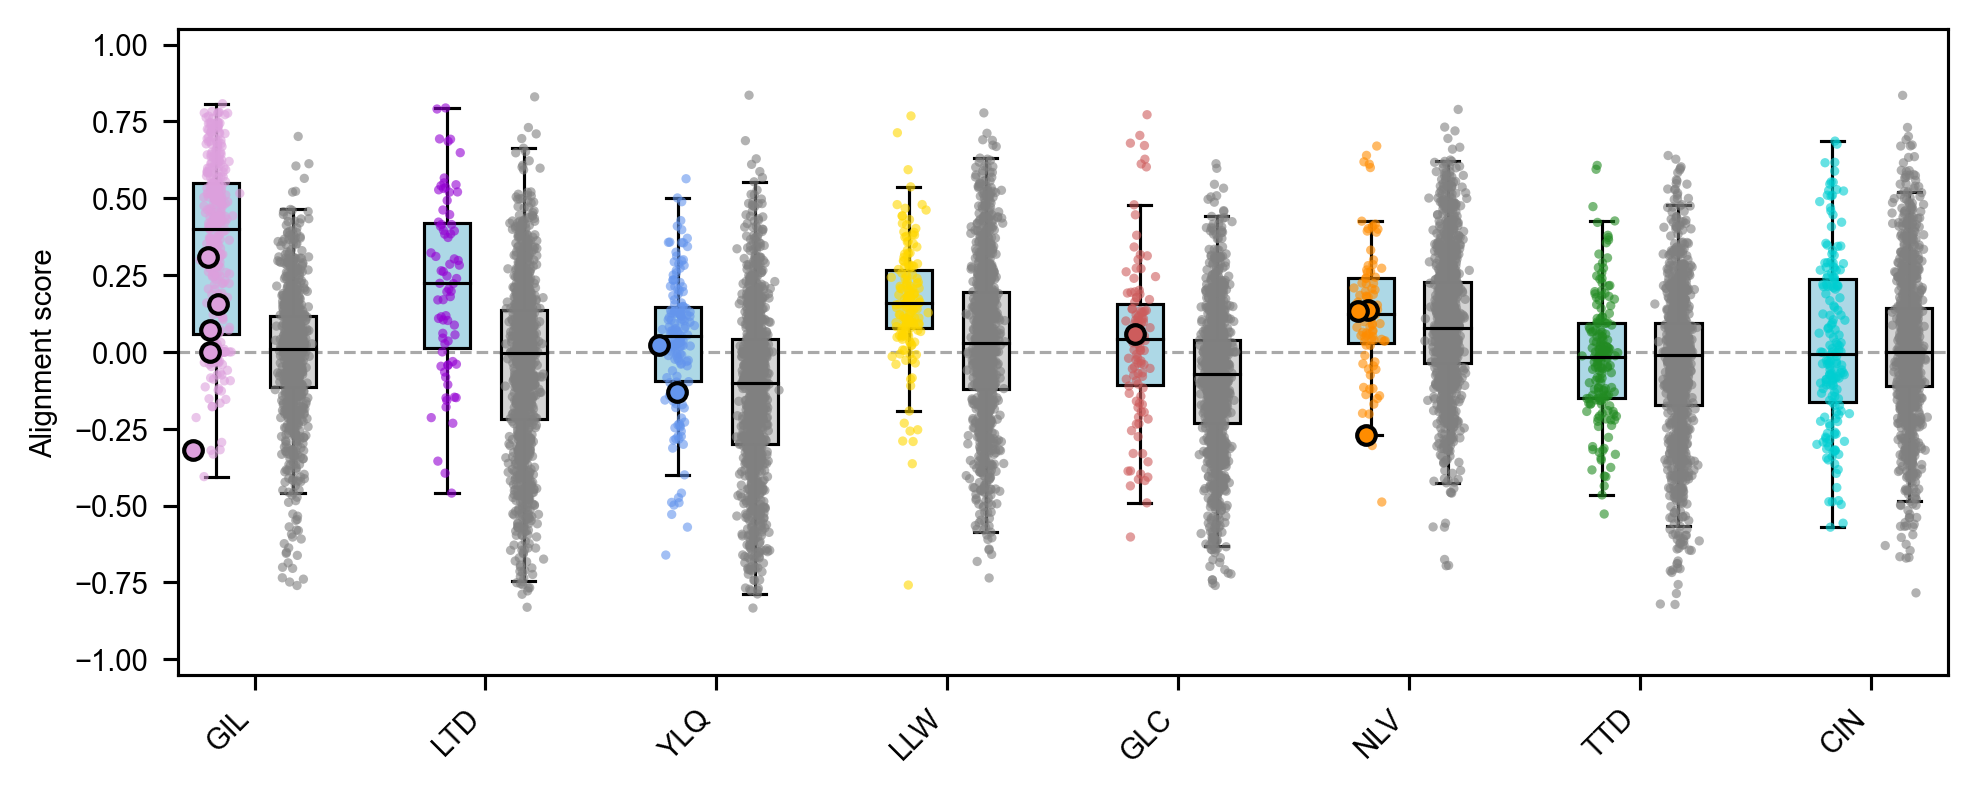

In [32]:
# set the seed using np
np.random.seed(42)

# the same, but now using all_closeness_scores, plot validating and non validating separately (2 boxplots per epitope)
# plt.figure(figsize=(15/2.54, 8/2.54)) # 12 x 7
plt.figure(figsize=(17/2.54, 7/2.54)) # 12 x 7
plt.axhline(0, color='darkgrey', linestyle='--', linewidth=mylines)

boxplot_data_validating = []
boxplot_data_nonvalidating = []
# all_epitopes_sorted = sorted(all_epitopes_for_swap, key=lambda x: np.median([all_closeness_scores[x]['closeness'][i] for i, label in enumerate(all_closeness_scores[x]['labels']) if label == 1]), reverse=True)   
# compute delta-median = median(validating) − median(nonvalidating)
delta_medians = {}
for epitope in all_epitopes_for_swap:
    vals = all_closeness_scores[epitope]['closeness']
    labs = all_closeness_scores[epitope]['labels']

    validating = [vals[i] for i,l in enumerate(labs) if l == 1]
    nonvalidating = [vals[i] for i,l in enumerate(labs) if l == 0]

    if len(validating) > 0 and len(nonvalidating) > 0:
        delta = np.median(validating) - np.median(nonvalidating)
    else:
        delta = float('-inf')

    delta_medians[epitope] = delta

all_epitopes_sorted = sorted(delta_medians.keys(),
                             key=lambda x: delta_medians[x],
                             reverse=True)

all_df_closeness_peptide = {}
for epitope in all_epitopes_sorted:   
    df_closeness_peptide = pd.DataFrame({
    'tcr_id': all_closeness_scores[epitope]['ids'],
    'closeness': all_closeness_scores[epitope]['closeness'],
    'label': all_closeness_scores[epitope]['labels'],
    })
    df_closeness_peptide['has_pdb'] = df_closeness_peptide['tcr_id'].apply(lambda x: x in tcr_with_pdb)

    
    closeness_scores = df_closeness_peptide['closeness'].tolist()
    labels = df_closeness_peptide['label'].tolist()

    validating_scores = [closeness_scores[i] for i, label in enumerate(labels) if label == 1]
    nonvalidating_scores = [closeness_scores[i] for i, label in enumerate(labels) if label == 0]
    boxplot_data_validating.append(validating_scores)
    boxplot_data_nonvalidating.append(nonvalidating_scores)
    all_df_closeness_peptide[epitope] = df_closeness_peptide
# but dont plot the outliers
# positions_validating = np.arange(1, len(all_epitopes_sorted)*2+1, 2)
# positions_nonvalidating = np.arange(2, len(all_epitopes_sorted)*2+1, 2)

positions_validating = np.arange(1, len(all_epitopes_sorted)*3, 3)
positions_nonvalidating = positions_validating + 1

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

pvals = []
for v_scores, nv_scores in zip(boxplot_data_validating,
                               boxplot_data_nonvalidating):
    if len(v_scores) > 0 and len(nv_scores) > 0:
        _, p = mannwhitneyu(v_scores, nv_scores, alternative='two-sided')
    else:
        p = float('nan')
    pvals.append(p)

# BH-FDR
rejected, pvals_corrected, _, _ = multipletests(pvals, method='fdr_bh')
# print, with scientific notation and 2 decimal places
print([f"{p:.1e}" for p in pvals_corrected])

plt.boxplot(boxplot_data_validating, 
            positions=positions_validating, 
            widths=0.6, 
            patch_artist=True, 
            boxprops=dict(facecolor='lightblue',
                          linewidth=mylines,  
                          ),  
            flierprops=dict(markersize=0,
                            linewidth=mylines, 
                            ),
            medianprops=dict(linewidth=mylines, color='black'),
            capprops=dict(linewidth=mylines),
            whiskerprops=dict(linewidth=mylines),
            ),

plt.boxplot(boxplot_data_nonvalidating, 
            positions=positions_nonvalidating, 
            widths=0.6, 
            patch_artist=True, 
            # mean line is orange but i want it black
            boxprops=dict(facecolor='lightgrey',
                          linewidth=mylines,  
                          ),
            flierprops=dict(markersize=0,
                            linewidth=mylines, 
                            ),
            medianprops=dict(linewidth=mylines, color='black'),
            capprops=dict(linewidth=mylines),
            whiskerprops=dict(linewidth=mylines),
            )

            
for i, epitope in enumerate(all_epitopes_sorted):   
    df_closeness_peptide = all_df_closeness_peptide[epitope]
    y_validating = [df_closeness_peptide['closeness'][j] for j, label in enumerate(df_closeness_peptide['label']) if label == 1]
    x_validating = np.random.normal(positions_validating[i], 0.08, size=len(y_validating))  # jittered x values
    plt.scatter(x_validating, y_validating, alpha=0.6, 
                color=name_color_dict[epitope],
                  s=5, 
                  zorder=2,
                edgecolors='none'
                )
    print(len(y_validating), epitope)
    y_validating_pdb = [df_closeness_peptide['closeness'][j] for j, (label, pdb) in enumerate(zip(df_closeness_peptide['label'], df_closeness_peptide['has_pdb'])) if label == 1 and pdb]
    x_validating_pdb = np.random.normal(positions_validating[i], 0.14, size=len(y_validating_pdb))  # jittered x values
    plt.scatter(x_validating_pdb, 
                y_validating_pdb, 
                alpha=1.0, 
                color=name_color_dict[epitope],
                  s=20, zorder=3,
                edgecolors='black',
                linewidths=1.0,
                # label='Validating TCRs with PDB' if i ==0 else ""
                )

    y_nonvalidating = [df_closeness_peptide['closeness'][j] for j, label in enumerate(df_closeness_peptide['label']) if label == 0]
    x_nonvalidating = np.random.normal(positions_nonvalidating[i], 0.08, size=len(y_nonvalidating))  # jittered x values
    plt.scatter(x_nonvalidating, y_nonvalidating, 
                alpha=0.6, 
                color='grey', 
                s=5, 
                zorder=2,
                edgecolors='none'
                )
    
    # y_nonvalidating_pdb = [df_closeness_peptide['closeness'][j] for j, (label, pdb) in enumerate(zip(df_closeness_peptide['label'], df_closeness_peptide['has_pdb'])) if label == 0 and pdb]
    # x_nonvalidating_pdb = np.random.normal(positions_nonvalidating[i], 0.15, size=len(y_nonvalidating_pdb))  # jittered x values
    # plt.scatter(x_nonvalidating_pdb, 
    #             y_nonvalidating_pdb, 
    #             alpha=1.0, 
    #             color='grey',
    #               s=10, zorder=3,
    #             edgecolors='black',
    #             # label='Non-validating TCRs with PDB' if i ==0 else ""
    #             ) 
plt.ylabel('Alignment score', fontsize=fontsize_axes)
plt.xticks(positions_validating + 0.5, [epitope[:3] for epitope in all_epitopes_sorted], rotation=45, ha='right')
# only first 3 char in x ticks

plt.ylim(-1.05, 1.05)
plt.legend(fontsize=7)
plt.savefig(out_path_dropbox + f'swap_boxplot-closeness.pdf', dpi=300, bbox_inches='tight')
plt.show()